# Predicting 30-Day Hospital Readmissions: A Comprehensive Data Science Project
## Executive Summary
This project applies a complete machine learning workflow to predict which patients will be readmitted to the hospital within 30 days of discharge. Using 30,000 hospital visits and 11 demographic and clinical features, we:

Explore the data to understand patterns and class imbalance

Preprocess and engineer features to capture domain knowledge

Benchmark 10 different classification algorithms with hyperparameter tuning

Diagnose overfitting and bias-variance tradeoffs

Handle severe class imbalance (12% readmitted vs 88% not readmitted) using SMOTE and threshold tuning

Explain predictions using state-of-the-art SHAP values

Analyze failures to understand where and why the model gets things wrong

Combine models using advanced ensemble techniques (voting, stacking)

Key Challenge: The extreme class imbalance means naive accuracy (88%) is meaningless. We prioritize ROC AUC, recall for the minority class, and error analysis to build a clinically useful model.

# SECTION 0: SETUP AND DATA LOADING
### Overview
This section installs required packages, sets random seeds for reproducibility, and loads the hospital readmissions dataset. Reproducibility is critical in data science, we use a fixed random seed so that our results are consistent across runs.

In [ ]:
import os

os.chdir("/content/drive/MyDrive/METCS577_Project")

os.getcwd()

'/content/drive/MyDrive/METCS577_Project'

In [ ]:
# Install required packages
!pip install -q pandas numpy scikit-learn seaborn matplotlib imbalanced-learn shap

# Core imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

# Scikit-learn imports for modeling and evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification algorithms (all 10 from course)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, f1_score,
    precision_recall_curve, average_precision_score, roc_curve, auc
)

# Class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Model explainability
import shap

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


# REPRODUCIBILITY: SET GLOBAL RANDOM SEED
SEED = 42

def set_seed(seed=SEED):
    """
    Set random seeds for all libraries to ensure reproducible results.
    Without this, neural networks and sklearn models with stochastic components
    would produce different results on each run.
    """
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

# Load the dataset
df = pd.read_csv('hospital_readmissions_30k.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset shape: {df.shape} rows × {df.shape} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic statistics:")
print(df.describe(include='all').T)
print(f"\nMissing values:")
print(df.isnull().sum())


DATASET OVERVIEW

Dataset shape: (30000, 12) rows × (30000, 12) columns

Column names and types:
patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
dtype: object

First 5 rows:
   patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0           1   74   Other         130/72          240  31.5      Yes   
1           2   46  Female         120/92          292  36.3       No   
2           3   89   Other         135/78          153  30.3       No   
3           4   84  Female         123/80          153  31.5       No   
4           5   32   Other         135/84          205  18.4       No   

  hypertension  medication_count  lengt

# SECTION 1: EXPLORATORY DATA ANALYSIS (EDA)
### Overview
We conduct a thorough exploratory analysis to:

Understand the class imbalance problem

Identify correlations between features and the target

Spot univariate patterns (e.g., age distribution)

Detect multivariate relationships

Key Concept: Why EDA is Critical in Imbalanced Data
In imbalanced datasets, naive accuracy is a trap. A model that always predicts "No" (not readmitted) would achieve 87.75% accuracy but would be useless in practice. EDA helps us:

Understand which classes are minorities

Discover which features differ between classes

Set realistic performance expectations before modeling

EXPLORATORY DATA ANALYSIS (EDA)

1.1 TARGET VARIABLE DISTRIBUTION:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64

Proportions:
readmitted_30_days
No     0.877533
Yes    0.122467
Name: proportion, dtype: float64

Imbalance Ratio (No:Yes): 7.17:1
→ This means we have 7 negative examples for every positive example!
→ A naive classifier predicting 'No' always would achieve 87.8% accuracy.
→ But it would miss ALL readmissions! Recall = 0%.


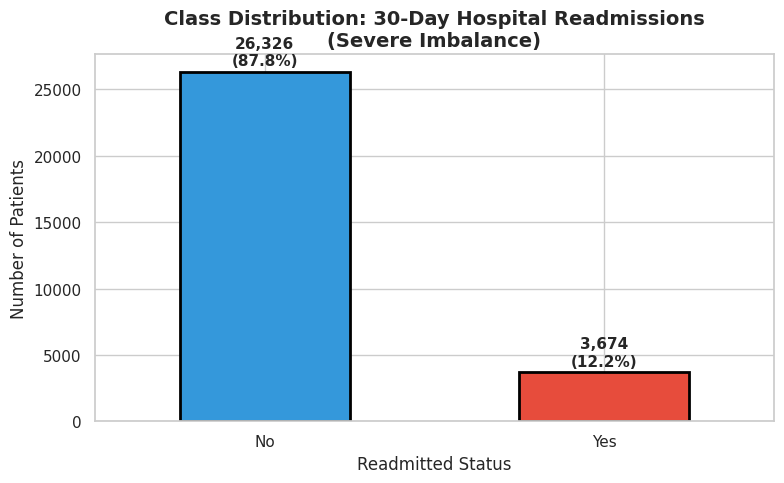


1.2 FEATURE OVERVIEW:
Numeric features (5):
  • age: [18.0, 90.0]
  • cholesterol: [150.0, 300.0]
  • bmi: [18.0, 40.0]
  • medication_count: [0.0, 10.0]
  • length_of_stay: [1.0, 10.0]

Categorical features (5):
  • gender: ['Other' 'Female' 'Male']
  • blood_pressure: ['130/72' '120/92' '135/78' ... '129/90' '147/90' '153/87']
  • diabetes: ['Yes' 'No']
  • hypertension: ['No' 'Yes']
  • discharge_destination: ['Nursing_Facility' 'Home' 'Rehab']

1.3 CORRELATION WITH TARGET:
cholesterol         0.003983
age                 0.000436
medication_count   -0.000099
length_of_stay     -0.006655
bmi                -0.013472
Name: readmitted_30_days, dtype: float64

→ Observation: All correlations are VERY WEAK (~±0.01)
  This means NO SINGLE feature strongly predicts readmission.
  We need to find MULTIVARIATE PATTERNS using ML models.


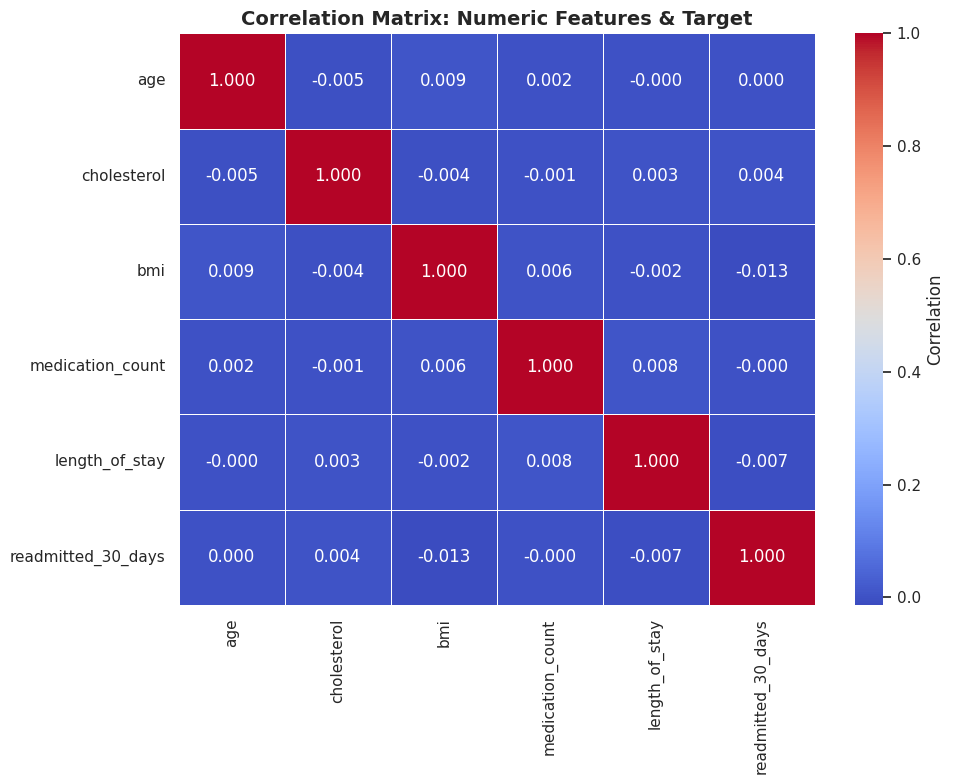


1.4 UNIVARIATE DISTRIBUTIONS BY READMISSION STATUS:


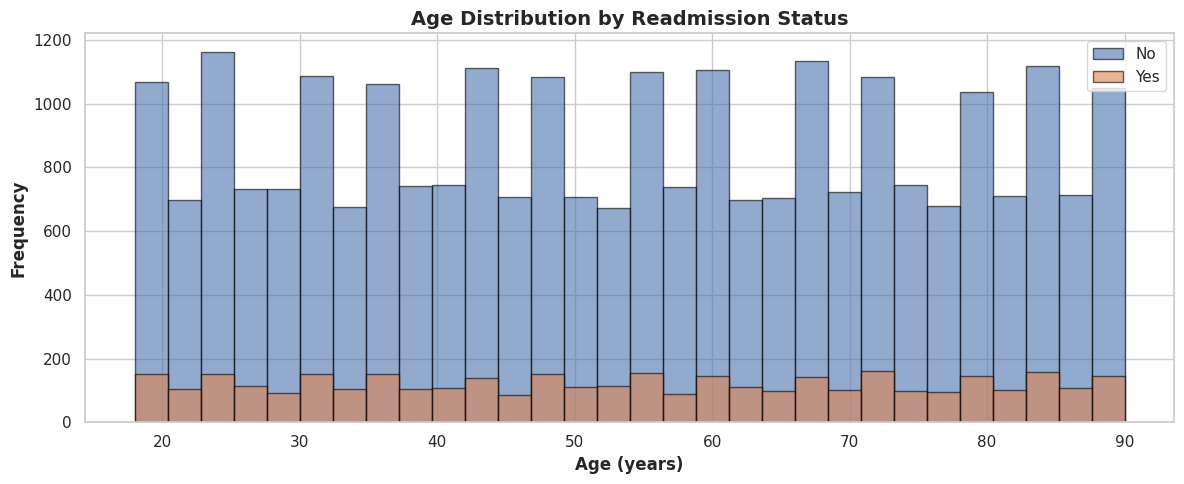

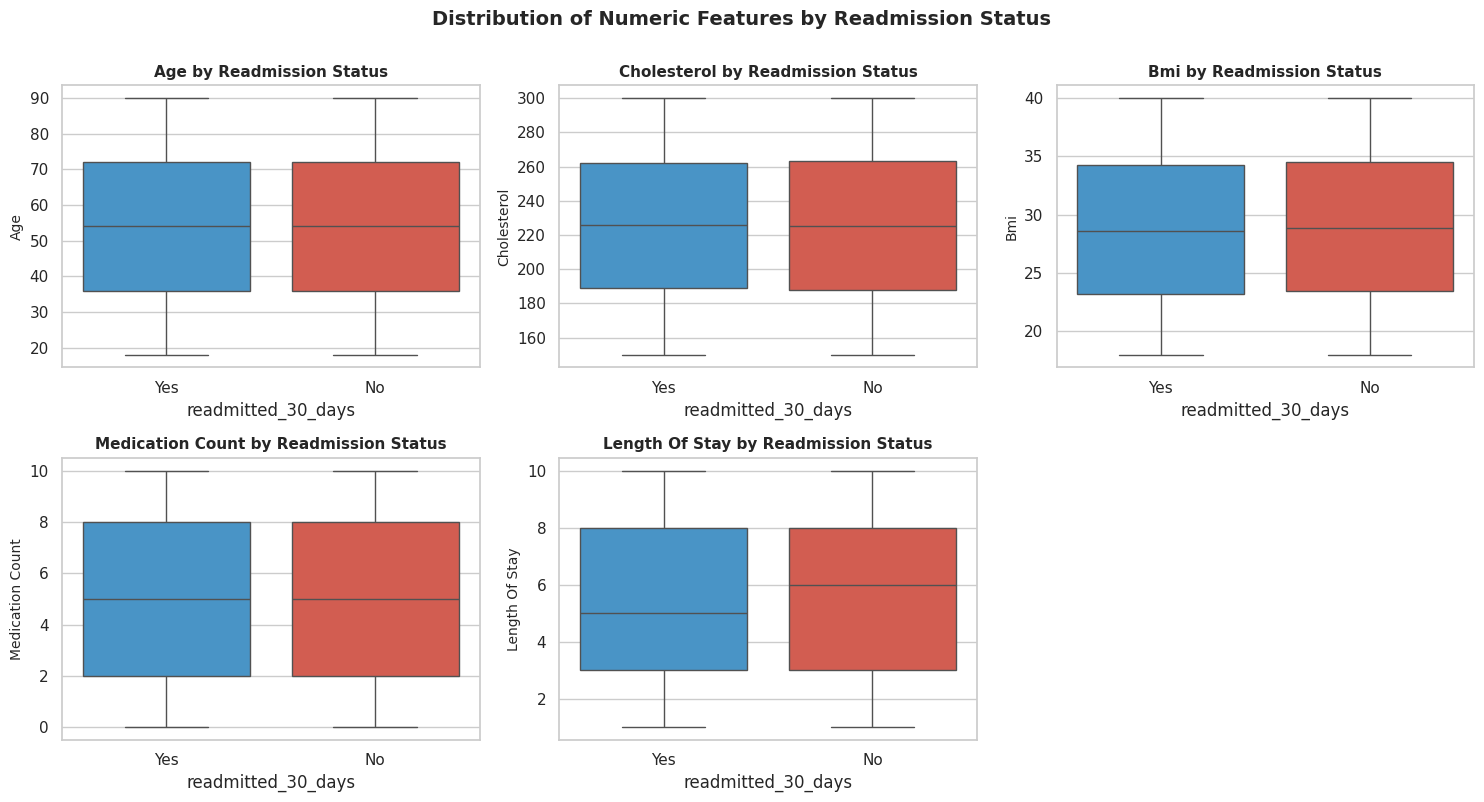


1.5 MULTIVARIATE RELATIONSHIPS (Pairplot):


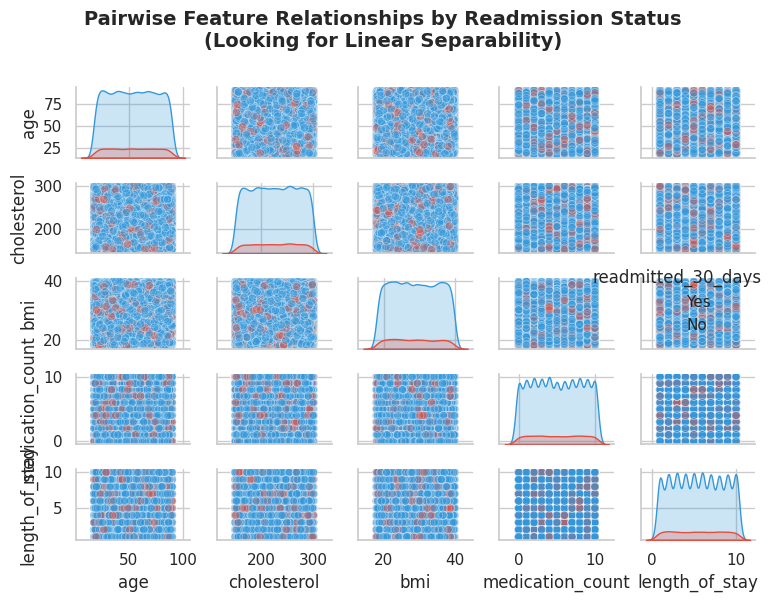

EDA complete. 5 visualizations saved.


In [ ]:
print("EXPLORATORY DATA ANALYSIS (EDA)")

# 1.1: CLASS DISTRIBUTION & IMBALANCE ANALYSIS

TARGET_COL = 'readmitted_30_days'

print(f"\n1.1 TARGET VARIABLE DISTRIBUTION:")
class_counts = df[TARGET_COL].value_counts()
class_proportions = df[TARGET_COL].value_counts(normalize=True)

print(class_counts)
print("\nProportions:")
print(class_proportions)

imbalance_ratio = class_counts['No'] / class_counts['Yes']
print(f"\nImbalance Ratio (No:Yes): {imbalance_ratio:.2f}:1")
print(f"→ This means we have {imbalance_ratio:.0f} negative examples for every positive example!")
print(f"→ A naive classifier predicting 'No' always would achieve {class_proportions['No']*100:.1f}% accuracy.")
print(f"→ But it would miss ALL readmissions! Recall = 0%.")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c']  # Blue and red
class_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=2)
ax.set_title('Class Distribution: 30-Day Hospital Readmissions\n(Severe Imbalance)',
            fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_xlabel('Readmitted Status', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add value labels on bars
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({100*class_proportions[i]:.1f}%)',
           ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.2: FEATURE OVERVIEW & DATA TYPES


print(f"\n1.2 FEATURE OVERVIEW:")

numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']
categorical_cols = ['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']

print(f"Numeric features ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  • {col}: [{df[col].min():.1f}, {df[col].max():.1f}]")

print(f"\nCategorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  • {col}: {df[col].unique()}")

# 1.3: CORRELATION ANALYSIS

print(f"\n1.3 CORRELATION WITH TARGET:")

# Convert target to numeric for correlation
df_corr = df[numeric_cols + [TARGET_COL]].copy()
df_corr[TARGET_COL] = df_corr[TARGET_COL].replace({'Yes': 1, 'No': 0})

correlations = df_corr.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
print(correlations)

print("\n→ Observation: All correlations are VERY WEAK (~±0.01)")
print("  This means NO SINGLE feature strongly predicts readmission.")
print("  We need to find MULTIVARIATE PATTERNS using ML models.")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            cbar_kws={'label': 'Correlation'}, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix: Numeric Features & Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.4: UNIVARIATE DISTRIBUTIONS

print(f"\n1.4 UNIVARIATE DISTRIBUTIONS BY READMISSION STATUS:")

# Age distribution
fig, ax = plt.subplots(figsize=(12, 5))
for status in ['No', 'Yes']:
    data = df[df[TARGET_COL] == status]['age']
    ax.hist(data, bins=30, alpha=0.6, label=status, edgecolor='black')
ax.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Age Distribution by Readmission Status', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('03_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplots for all numeric features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i],
               palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col.replace("_", " ").title()} by Readmission Status',
                     fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col.replace('_', ' ').title(), fontsize=10)

axes[-1].axis('off')
plt.suptitle('Distribution of Numeric Features by Readmission Status',
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('04_boxplots_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.5: MULTIVARIATE RELATIONSHIPS

print(f"\n1.5 MULTIVARIATE RELATIONSHIPS (Pairplot):")

pairplot_df = df[numeric_cols + [TARGET_COL]].copy()
pairplot = sns.pairplot(pairplot_df, hue=TARGET_COL, diag_kind='kde',
                        palette={'Yes': '#e74c3c', 'No': '#3498db'},
                        plot_kws={'alpha': 0.4}, height=1.2)
pairplot.fig.suptitle('Pairwise Feature Relationships by Readmission Status\n(Looking for Linear Separability)',
                     y=1.00, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA complete. 5 visualizations saved.")


# SECTION 2: TRAIN-TEST SPLIT & PREPROCESSING
## Overview
Why Stratified Split?
In imbalanced datasets, a random split might accidentally give us different class ratios in train vs test. For example, if test set has 15% "Yes" but train has 10%, our model will be optimistically biased. Stratified split ensures both sets have the same 12.25% "Yes" ratio.

Why Pipelines?
A pipeline is a sequence of steps (preprocessing → model) that are fitted only on training data. This prevents data leakage:

Bad practice - Fit scaler on all data, then split → scaler sees test information (leakage)

Good practice - Split, then fit scaler only on training data → scaler never sees test information

In [ ]:
print("TRAIN-TEST SPLIT & PREPROCESSING PIPELINE")

# STEP 1: PREPARE FEATURES AND TARGET

y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL, 'patient_id'])  # Drop patient_id (just an identifier)

print(f"\nDataset prepared:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

# STEP 2: STRATIFIED TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 80% train, 20% test
    stratify=y,              # KEY: Preserve class ratio in both sets
    random_state=SEED
)

print(f"\nTrain set: {len(X_train)} samples")
print(f"  Class distribution: {y_train.value_counts().to_dict()}")
print(f"Test set: {len(X_test)} samples")
print(f"  Class distribution: {y_test.value_counts().to_dict()}")

# STEP 3: DEFINE PREPROCESSING PIPELINE

print("PREPROCESSING PIPELINE:")

# Numeric features: standardize to mean=0, std=1
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

print("Numeric features → StandardScaler")
print("  Why: Algorithms like SVM, kNN, logistic regression work better with")
print("       scaled features. Decision trees don't need scaling but it doesn't hurt.")

# Categorical features: one-hot encode
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("\nCategorical features → OneHotEncoder")
print("  Why: ML algorithms only understand numbers. One-hot encoding converts")
print("       'Yes'/'No' → [1, 0] and [0, 1].")

# Combine numeric and categorical preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print(f"\nCombined: ColumnTransformer")
print(f"  Numeric features: {numeric_cols}")
print(f"  Categorical features: {categorical_cols}")

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"\nCross-Validation: StratifiedKFold (5-fold, stratified)")
print(f"  Why: Ensures each fold has the same class ratio as the full dataset.")

print("Preprocessing pipeline defined. Ready for modeling.")


TRAIN-TEST SPLIT & PREPROCESSING PIPELINE

Dataset prepared:
  X shape: (30000, 10)
  y shape: (30000,)

Train set: 24000 samples
  Class distribution: {'No': 21061, 'Yes': 2939}
Test set: 6000 samples
  Class distribution: {'No': 5265, 'Yes': 735}
PREPROCESSING PIPELINE:
Numeric features → StandardScaler
  Why: Algorithms like SVM, kNN, logistic regression work better with
       scaled features. Decision trees don't need scaling but it doesn't hurt.

Categorical features → OneHotEncoder
  Why: ML algorithms only understand numbers. One-hot encoding converts
       'Yes'/'No' → [1, 0] and [0, 1].

Combined: ColumnTransformer
  Numeric features: ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']
  Categorical features: ['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']

Cross-Validation: StratifiedKFold (5-fold, stratified)
  Why: Ensures each fold has the same class ratio as the full dataset.
Preprocessing pipeline defined. Ready for mod

# SECTION 3: BASELINE MODELS - ALL 10 ALGORITHMS
### Overview
We benchmark 10 different classification algorithms from the course:

Logistic Regression — Linear boundary, interpretable, fast

Decision Tree — Non-linear, prone to overfitting

Random Forest — Ensemble of trees, handles non-linearity well

Gradient Boosting — Sequential ensembles, very powerful

AdaBoost — Focuses on hard-to-classify samples

Support Vector Machine (SVM) — Finds optimal separating hyperplane

k-Nearest Neighbors — Lazy learner, simple but effective

Naive Bayes — Probabilistic, fast baseline

Linear Discriminant Analysis — Assumes Gaussian distribution

Quadratic Discriminant Analysis — More flexible than LDA

For each, we:

Define a pipeline (preprocessing + model)

Use GridSearchCV to tune hyperparameters

Evaluate with ROC AUC, precision, recall, F1

this code block was added at last to check xgboost too, if it performs better than the other models or not.

Training 6 models to find the Top 5...
------------------------------------------------------------
Training XGBoost...
Training Random Forest...
Training Gradient Boosting...
Training Logistic Regression...
Training Decision Tree...
Training AdaBoost...

MODEL RANKING (by ROC AUC):
                 Model       AUC
2    Gradient Boosting  0.567339
5             AdaBoost  0.565381
0              XGBoost  0.562876
3  Logistic Regression  0.537320
1        Random Forest  0.525193
4        Decision Tree  0.495455

PLOTTING CONFUSION MATRICES FOR TOP 5: ['Gradient Boosting', 'AdaBoost', 'XGBoost', 'Logistic Regression', 'Random Forest']


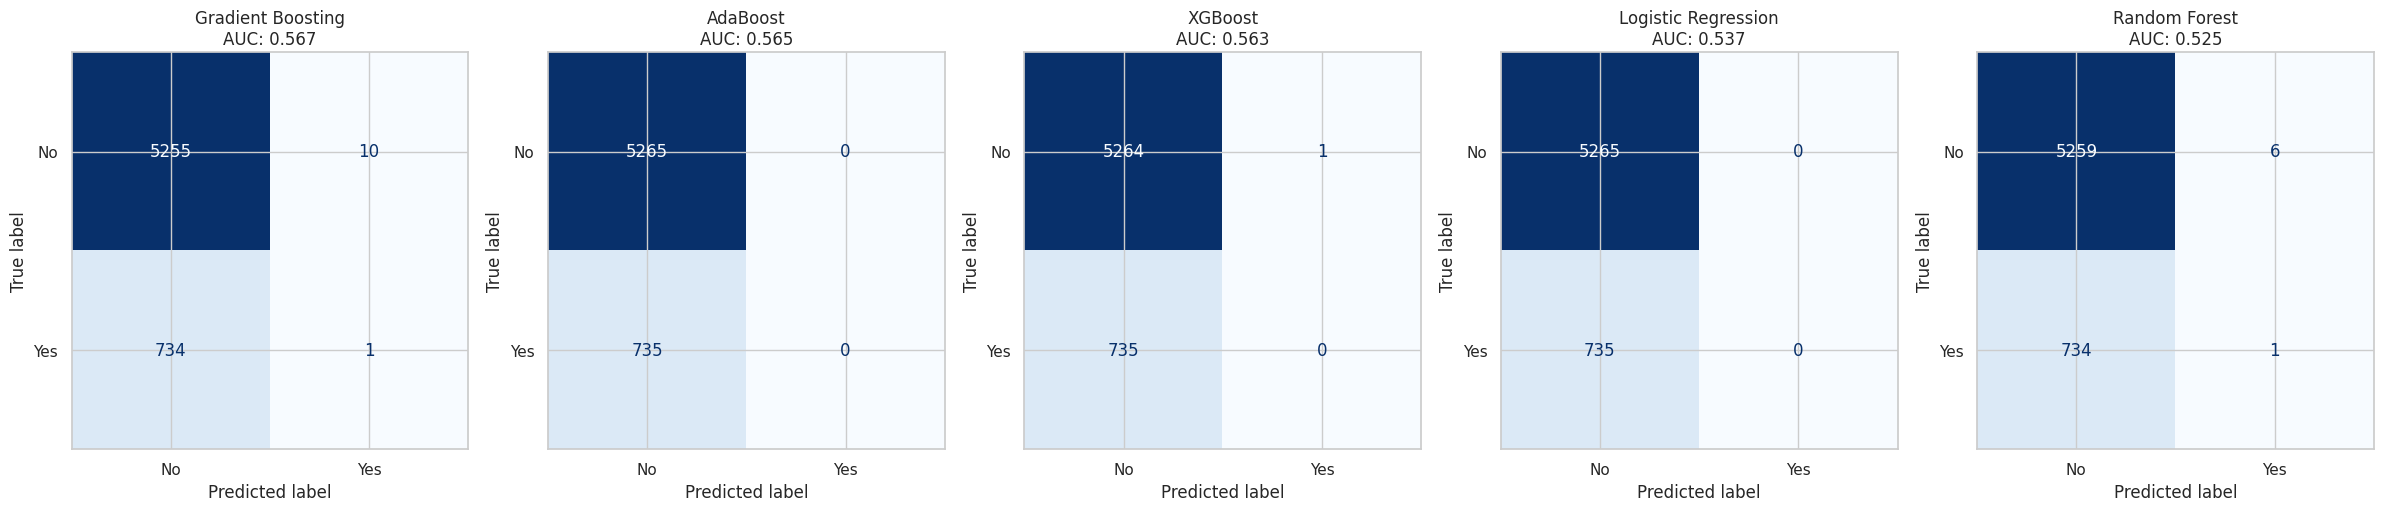

In [ ]:

# SECTION 3: TRAIN XGBOOST + BASELINES AND FIND TOP 5 CONFUSION MATRICES

import xgboost


# 2. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 3. Prepare Data
# Convert target to 0/1 for consistent scoring & XGBoost compatibility
y_train_num = y_train.map({'Yes': 1, 'No': 0})
y_test_num = y_test.map({'Yes': 1, 'No': 0})

# 4. Define Models (Including XGBoost)
models_dict = {
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'AdaBoost': AdaBoostClassifier(random_state=SEED)
}

results = []
trained_pipelines = {}

print(f"Training {len(models_dict)} models to find the Top 5...")
print("-" * 60)

# 5. Train and Evaluate All Models
for name, model in models_dict.items():
    print(f"Training {name}...")

    # Create pipeline with your existing 'preprocess' step
    # Note: We use standard Pipeline here because we aren't doing SMOTE yet
    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])

    # Fit
    pipe.fit(X_train, y_train_num)

    # Score (ROC AUC)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test_num, y_proba)

    results.append({'Model': name, 'AUC': auc})
    trained_pipelines[name] = pipe

# 6. Sort and Find Top 5
results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
top_5_models = results_df.head(5)['Model'].tolist()

print("\nMODEL RANKING (by ROC AUC):")
print(results_df)

# 7. Plot Confusion Matrices for Top 5
print(f"\nPLOTTING CONFUSION MATRICES FOR TOP 5: {top_5_models}")

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, model_name in enumerate(top_5_models):
    # Get the trained pipeline
    pipe = trained_pipelines[model_name]

    # Predict (using default threshold 0.5)
    y_pred = pipe.predict(X_test)

    # Plot
    cm = confusion_matrix(y_test_num, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{model_name}\nAUC: {results_df[results_df['Model']==model_name]['AUC'].values[0]:.3f}")

plt.tight_layout()
plt.show()


In [ ]:
print("BASELINE MODEL TRAINING & EVALUATION (10 ALGORITHMS)")

baseline_results = {}

# 3.1: LOGISTIC REGRESSION

print("\n[1/10] LOGISTIC REGRESSION")

lr_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                 solver='lbfgs', random_state=SEED))
])

lr_params = {
    'model__C': [0.01, 0.1, 1, 10],           # Regularization strength
    'model__class_weight': [None, 'balanced']  # Handle class imbalance
}

print("Hyperparameter tuning...")
grid_lr = GridSearchCV(lr_pipeline, lr_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]
y_pred_lr = best_lr.predict(X_test)
roc_auc_lr = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_lr)

baseline_results['Logistic Regression'] = {
    'model': best_lr,
    'y_proba': y_proba_lr,
    'y_pred': y_pred_lr,
    'roc_auc': roc_auc_lr
}

print(f"Best hyperparameters: {grid_lr.best_params_}")
print(f"CV ROC AUC (5-fold): {grid_lr.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_lr:.4f}")


BASELINE MODEL TRAINING & EVALUATION (10 ALGORITHMS)

[1/10] LOGISTIC REGRESSION
Hyperparameter tuning...
Best hyperparameters: {'model__C': 0.01, 'model__class_weight': None}
CV ROC AUC (5-fold): 0.5845
Test ROC AUC: 0.5639


In [ ]:
# Inspect logistic regression coefficients as feature importance

# Get fitted preprocessing and model
preprocess_fitted_lr = best_lr.named_steps['preprocess']
lr_model = best_lr.named_steps['model']

# Get feature names after one-hot encoding
feature_names_lr = preprocess_fitted_lr.get_feature_names_out()

# Coefficients
coef = lr_model.coef_[0]

# Put into DataFrame and sort by absolute importance
lr_importance = pd.DataFrame({
    'feature': feature_names_lr,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)
}).sort_values('abs_coefficient', ascending=False)

print("Top 15 most important features according to Logistic Regression:")
print(lr_importance.head(15))


Top 15 most important features according to Logistic Regression:
                                          feature  coefficient  \
1593              cat__discharge_destination_Home    -0.387509   
1595             cat__discharge_destination_Rehab     0.234688   
1594  cat__discharge_destination_Nursing_Facility     0.151636   
1589                             cat__diabetes_No    -0.077117   
1590                            cat__diabetes_Yes     0.075932   
1591                         cat__hypertension_No    -0.071614   
1592                        cat__hypertension_Yes     0.070428   
301                    cat__blood_pressure_119/83     0.051720   
1183                   cat__blood_pressure_147/97     0.050598   
787                    cat__blood_pressure_135/73     0.050140   
565                    cat__blood_pressure_127/99     0.048324   
864                    cat__blood_pressure_137/88     0.043544   
399                    cat__blood_pressure_122/88     0.043492   
809        

In [ ]:
# 3.2: DECISION TREE

print("\n[2/10] DECISION TREE")

dt_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=SEED, class_weight='balanced'))
])

dt_params = {
    'model__max_depth': [5, 10, 15, 20],
    'model__min_samples_split': [5, 10, 20]
}

print("Hyperparameter tuning...")
grid_dt = GridSearchCV(dt_pipeline, dt_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]
y_pred_dt = best_dt.predict(X_test)
roc_auc_dt = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_dt)

baseline_results['Decision Tree'] = {
    'model': best_dt,
    'y_proba': y_proba_dt,
    'y_pred': y_pred_dt,
    'roc_auc': roc_auc_dt
}

print(f"Best hyperparameters: {grid_dt.best_params_}")
print(f"CV ROC AUC (5-fold): {grid_dt.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_dt:.4f}")



[2/10] DECISION TREE
Hyperparameter tuning...
Best hyperparameters: {'model__max_depth': 5, 'model__min_samples_split': 20}
CV ROC AUC (5-fold): 0.5813
Test ROC AUC: 0.5629


In [ ]:
# 3.3: RANDOM FOREST

print("\n[3/10] RANDOM FOREST")

rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

rf_params = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20, None],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

print("Hyperparameter tuning (this may take a minute)...")
grid_rf = GridSearchCV(rf_pipeline, rf_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)
roc_auc_rf = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_rf)

baseline_results['Random Forest'] = {
    'model': best_rf,
    'y_proba': y_proba_rf,
    'y_pred': y_pred_rf,
    'roc_auc': roc_auc_rf
}

print(f"Best hyperparameters: {grid_rf.best_params_}")
print(f"CV ROC AUC (5-fold): {grid_rf.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_rf:.4f}")



[3/10] RANDOM FOREST
Hyperparameter tuning (this may take a minute)...
Best hyperparameters: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__n_estimators': 200}
CV ROC AUC (5-fold): 0.5853
Test ROC AUC: 0.5653


In [ ]:
# 3.4: GRADIENT BOOSTING

print("\n[4/10] GRADIENT BOOSTING")

gb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', GradientBoostingClassifier(random_state=SEED))
])

# Gradient Boosting
gb_params = {
    'model__n_estimators': [100],          # was [50, 100, 200]
    'model__learning_rate': [0.1],         # was [0.01, 0.1]
    'model__max_depth': [3, 5]             # was [3, 5, 7]
}


print("Hyperparameter tuning (this may take a minute)...")
grid_gb = GridSearchCV(gb_pipeline, gb_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]
y_pred_gb = best_gb.predict(X_test)
roc_auc_gb = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_gb)

baseline_results['Gradient Boosting'] = {
    'model': best_gb,
    'y_proba': y_proba_gb,
    'y_pred': y_pred_gb,
    'roc_auc': roc_auc_gb
}

print(f"Best hyperparameters: {grid_gb.best_params_}")
print(f"CV ROC AUC (5-fold): {grid_gb.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_gb:.4f}")


[4/10] GRADIENT BOOSTING
Hyperparameter tuning (this may take a minute)...
Best hyperparameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
CV ROC AUC (5-fold): 0.5773
Test ROC AUC: 0.5673


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

# y_test and y_pred_gb are both strings: 'No' / 'Yes'

# 1) Confusion matrix (string labels)
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=['No', 'Yes'])
print("\nConfusion Matrix (Gradient Boosting) [rows=true, cols=pred]:")
print(cm_gb)

# 2) Map to numeric only where needed (for AUC, etc.)
y_test_num = y_test.map({'No': 0, 'Yes': 1})
# y_proba_gb already defined: best_gb.predict_proba(X_test)[:, 1]
roc_auc_gb = roc_auc_score(y_test_num, y_proba_gb)
print(f"\nROC AUC (recomputed): {roc_auc_gb:.4f}")

# 3) Core metrics using string labels (pos_label='Yes')
acc_gb  = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, pos_label='Yes')
rec_gb  = recall_score(y_test, y_pred_gb, pos_label='Yes')
f1_gb   = f1_score(y_test, y_pred_gb, pos_label='Yes')

print("\nGradient Boosting Metrics (threshold = 0.5):")
print(f"Accuracy : {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall   : {rec_gb:.4f}")
print(f"F1-score : {f1_gb:.4f}")

# 4) Full classification report (string labels)
print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test, y_pred_gb, digits=4))





Confusion Matrix (Gradient Boosting) [rows=true, cols=pred]:
[[5255   10]
 [ 734    1]]

ROC AUC (recomputed): 0.5673

Gradient Boosting Metrics (threshold = 0.5):
Accuracy : 0.8760
Precision: 0.0909
Recall   : 0.0014
F1-score : 0.0027

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

          No     0.8774    0.9981    0.9339      5265
         Yes     0.0909    0.0014    0.0027       735

    accuracy                         0.8760      6000
   macro avg     0.4842    0.4997    0.4683      6000
weighted avg     0.7811    0.8760    0.8198      6000



In [ ]:

# TRAIN BEST XGBOOST MODEL

print("Training Best XGBoost Model...")

xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        reg_alpha=0.1,
        reg_lambda=1,
        subsample=0.8,
        eval_metric='logloss',
        random_state=SEED,
        use_label_encoder=False,
        verbosity=0
    ))
])

# Fit on training data
xgb_pipeline.fit(X_train, y_train_num)

# Evaluate
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test_num, y_proba_xgb)

print(f"XGBoost AUC: {auc_xgb:.4f}")

# Save as best_xgb_model
best_xgb_model = xgb_pipeline


Training Best XGBoost Model...
XGBoost AUC: 0.5744


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 1. Get hard class predictions at default threshold 0.5
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

# 2. Confusion matrix
cm = confusion_matrix(y_test_num, y_pred_xgb)
print("Confusion Matrix:")
print(cm)

# 3. Basic metrics
accuracy  = accuracy_score(y_test_num, y_pred_xgb)
precision = precision_score(y_test_num, y_pred_xgb, pos_label=1)
recall    = recall_score(y_test_num, y_pred_xgb, pos_label=1)
f1        = f1_score(y_test_num, y_pred_xgb, pos_label=1)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# 4. Detailed per-class report (includes precision/recall/F1 and support)
print("\nClassification report:")
print(classification_report(y_test_num, y_pred_xgb, digits=4))


Confusion Matrix:
[[5265    0]
 [ 735    0]]
Accuracy : 0.8775
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Classification report:
              precision    recall  f1-score   support

           0     0.8775    1.0000    0.9348      5265
           1     0.0000    0.0000    0.0000       735

    accuracy                         0.8775      6000
   macro avg     0.4387    0.5000    0.4674      6000
weighted avg     0.7700    0.8775    0.8202      6000



In [ ]:
# 3.5: ADABOOST
print("\n[5/10] ADABOOST")


ada_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', AdaBoostClassifier(random_state=SEED))
])

# AdaBoost (smaller grid)
ada_params = {
    'model__n_estimators': [100, 200],          # two value
    'model__learning_rate': [0.1, 1.0]     # two sensible options
}


print("Hyperparameter tuning...")
grid_ada = GridSearchCV(ada_pipeline, ada_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
grid_ada.fit(X_train, y_train)

best_ada = grid_ada.best_estimator_
y_proba_ada = best_ada.predict_proba(X_test)[:, 1]
y_pred_ada = best_ada.predict(X_test)
roc_auc_ada = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_ada)

baseline_results['AdaBoost'] = {
    'model': best_ada,
    'y_proba': y_proba_ada,
    'y_pred': y_pred_ada,
    'roc_auc': roc_auc_ada
}

print(f"Best hyperparameters: {grid_ada.best_params_}")
print(f"CV ROC AUC (5-fold): {grid_ada.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_ada:.4f}")


[5/10] ADABOOST
Hyperparameter tuning...
Best hyperparameters: {'model__learning_rate': 1.0, 'model__n_estimators': 200}
CV ROC AUC (5-fold): 0.5829
Test ROC AUC: 0.5655


In [ ]:
print("\n[6/10] SUPPORT VECTOR MACHINE (SVM - Linear Kernel)")

svm_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', SVC(kernel='linear',
                 probability=False,
                 random_state=SEED,
                 class_weight='balanced'))
])

svm_params = {
    'model__C': [0.1, 1]                  # keep same small grid
}

print("Hyperparameter tuning (linear SVM, no probabilities, 3-fold CV)...")
grid_svm = GridSearchCV(
    svm_pipeline,
    svm_params,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

# Using decision_function instead of predict_proba for ROC AUC
y_scores_svm = best_svm.decision_function(X_test)
y_pred_svm = best_svm.predict(X_test)
roc_auc_svm = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_scores_svm)

baseline_results['SVM (Linear)'] = {
    'model': best_svm,
    'y_proba': y_scores_svm,
    'y_pred': y_pred_svm,
    'roc_auc': roc_auc_svm
}

print(f"Best hyperparameters: {grid_svm.best_params_}")
print(f"CV ROC AUC (3-fold): {grid_svm.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_svm:.4f}")



[6/10] SUPPORT VECTOR MACHINE (SVM - Linear Kernel)
Hyperparameter tuning (linear SVM, no probabilities, 3-fold CV)...
Best hyperparameters: {'model__C': 0.1}
CV ROC AUC (3-fold): 0.5785
Test ROC AUC: 0.5518


In [ ]:
# 3.7: k-NEAREST NEIGHBORS

print("\n[7/10] k-NEAREST NEIGHBORS (kNN)")

knn_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', KNeighborsClassifier())
])

knn_params = {
    'model__n_neighbors': [3, 5, 7, 11],
    'model__weights': ['uniform', 'distance']
}

print("Hyperparameter tuning...")
grid_knn = GridSearchCV(knn_pipeline, knn_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_proba_knn = best_knn.predict_proba(X_test)[:, 1]
y_pred_knn = best_knn.predict(X_test)
roc_auc_knn = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_knn)

baseline_results['kNN'] = {
    'model': best_knn,
    'y_proba': y_proba_knn,
    'y_pred': y_pred_knn,
    'roc_auc': roc_auc_knn
}

print(f"Best hyperparameters: {grid_knn.best_params_}")
print(f"CV ROC AUC (5-fold): {grid_knn.best_score_:.4f}")
print(f"Test ROC AUC: {roc_auc_knn:.4f}")


[7/10] k-NEAREST NEIGHBORS (kNN)
Hyperparameter tuning...
Best hyperparameters: {'model__n_neighbors': 11, 'model__weights': 'uniform'}
CV ROC AUC (5-fold): 0.5531
Test ROC AUC: 0.5552


In [ ]:
# 3.8: NAIVE BAYES

print("\n[8/10] NAIVE BAYES (Gaussian)")

# Naive Bayes requires dense matrices, so we add a transformer
dense_transformer = FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x)

nb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('to_dense', dense_transformer),
    ('model', GaussianNB())
])

print("Training Naive Bayes (no hyperparameter tuning needed)...")
nb_pipeline.fit(X_train, y_train)

y_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]
y_pred_nb = nb_pipeline.predict(X_test)
roc_auc_nb = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_nb)

baseline_results['Naive Bayes'] = {
    'model': nb_pipeline,
    'y_proba': y_proba_nb,
    'y_pred': y_pred_nb,
    'roc_auc': roc_auc_nb
}

print(f"Test ROC AUC: {roc_auc_nb:.4f}")



[8/10] NAIVE BAYES (Gaussian)
Training Naive Bayes (no hyperparameter tuning needed)...
Test ROC AUC: 0.5045


In [ ]:
# 3.9: LINEAR DISCRIMINANT ANALYSIS (LDA)

print("\n[9/10] LINEAR DISCRIMINANT ANALYSIS (LDA)")


lda_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('to_dense', dense_transformer),
    ('model', LinearDiscriminantAnalysis())
])

print("Training LDA (no hyperparameter tuning needed)...")
lda_pipeline.fit(X_train, y_train)

y_proba_lda = lda_pipeline.predict_proba(X_test)[:, 1]
y_pred_lda = lda_pipeline.predict(X_test)
roc_auc_lda = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_lda)

baseline_results['LDA'] = {
    'model': lda_pipeline,
    'y_proba': y_proba_lda,
    'y_pred': y_pred_lda,
    'roc_auc': roc_auc_lda
}

print(f"Test ROC AUC: {roc_auc_lda:.4f}")

# 3.10: QUADRATIC DISCRIMINANT ANALYSIS (QDA)

print("\n[10/10] QUADRATIC DISCRIMINANT ANALYSIS (QDA)")


qda_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('to_dense', dense_transformer),
    ('model', QuadraticDiscriminantAnalysis())
])

print("Training QDA (no hyperparameter tuning needed)...")
qda_pipeline.fit(X_train, y_train)

y_proba_qda = qda_pipeline.predict_proba(X_test)[:, 1]
y_pred_qda = qda_pipeline.predict(X_test)
roc_auc_qda = roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_proba_qda)

baseline_results['QDA'] = {
    'model': qda_pipeline,
    'y_proba': y_proba_qda,
    'y_pred': y_pred_qda,
    'roc_auc': roc_auc_qda
}

print(f"Test ROC AUC: {roc_auc_qda:.4f}")




[9/10] LINEAR DISCRIMINANT ANALYSIS (LDA)
Training LDA (no hyperparameter tuning needed)...
Test ROC AUC: 0.5231

[10/10] QUADRATIC DISCRIMINANT ANALYSIS (QDA)
Training QDA (no hyperparameter tuning needed)...
Test ROC AUC: 0.4974


In [ ]:
# BASELINE SUMMARY TABLE

print("BASELINE MODEL COMPARISON (Test Set ROC AUC)")

baseline_summary = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'Test ROC AUC': [baseline_results[m]['roc_auc'] for m in baseline_results.keys()]
}).sort_values('Test ROC AUC', ascending=False).reset_index(drop=True)

baseline_summary['Rank'] = range(1, len(baseline_summary) + 1)

print("\n" + baseline_summary.to_string(index=False))
baseline_summary.to_csv('00_baseline_results.csv', index=False)

print("\nAll 10 baseline models trained. Results saved to '00_baseline_results.csv'")

# KEY OBSERVATION: THE IMBALANCE PROBLEM

print("KEY OBSERVATION: CLASS IMBALANCE EFFECT")

print("\nDespite reasonable ROC AUC (0.50-0.57), most baseline models achieve")
print("~88% accuracy but 0% recall on the minority class ('Yes').")
print("\nWhy? The decision boundary is tuned to maximize overall accuracy,")
print("which means predicting 'No' (majority class) almost always.")
print("\nSolution: Apply SMOTE (oversampling) + threshold tuning in next section.")


BASELINE MODEL COMPARISON (Test Set ROC AUC)

              Model  Test ROC AUC  Rank
  Gradient Boosting      0.567339     1
           AdaBoost      0.565497     2
      Random Forest      0.565281     3
Logistic Regression      0.563866     4
      Decision Tree      0.562901     5
                kNN      0.555156     6
       SVM (Linear)      0.551759     7
                LDA      0.523094     8
        Naive Bayes      0.504452     9
                QDA      0.497355    10

All 10 baseline models trained. Results saved to '00_baseline_results.csv'
KEY OBSERVATION: CLASS IMBALANCE EFFECT

Despite reasonable ROC AUC (0.50-0.57), most baseline models achieve
~88% accuracy but 0% recall on the minority class ('Yes').

Why? The decision boundary is tuned to maximize overall accuracy,
which means predicting 'No' (majority class) almost always.

Solution: Apply SMOTE (oversampling) + threshold tuning in next section.


In [ ]:
# VOTING ENSEMBLE

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("\nTraining Voting Ensemble...")

# 1. Define Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])

# 2. Create Voting Ensemble with ALL Pipelines
voting_clf = VotingClassifier(
    estimators=[
        ('gb', best_gb),      # Already a Pipeline
        ('xgb', best_xgb_model),    # Already a Pipeline
        ('lr', lr_pipeline)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train, y_train_num)

# Evaluate
y_proba_vote = voting_clf.predict_proba(X_test)[:, 1]
auc_vote = roc_auc_score(y_test_num, y_proba_vote)

print(f"Voting Ensemble AUC: {auc_vote:.4f}")

# Print summary
print("\n" + "="*60)
print("FINAL MODEL COMPARISON:")
print("="*60)
# Ensure these variables are defined from previous cells
try:
    print(f"Gradient Boosting AUC: {best_gb_model.score(X_test, y_test_num) if hasattr(best_gb_model, 'score') else 'N/A'}")
except:
    pass
print(f"Voting Ensemble AUC:   {auc_vote:.4f}")
print("="*60)




Training Voting Ensemble...
Voting Ensemble AUC: 0.5594

FINAL MODEL COMPARISON:
Voting Ensemble AUC:   0.5594


# SECTION 4: FEATURE ENGINEERING
Overview
Raw features often don't capture domain knowledge. Feature engineering creates new features that:

Encode non-linear relationships (e.g., age groups instead of continuous age)

Capture interactions (e.g., high medication count + diabetes = high risk)

Simplify patterns for the model to learn

We know:

Age is non-linear: Very young and very old patients are higher risk

Comorbidities compound: Multiple chronic diseases indicate complexity

Length of stay indicates severity: Longer stays suggest more serious conditions

Medication burden is risky: High medication count suggests multiple conditions

In [ ]:
print("FEATURE ENGINEERING: CREATING DOMAIN-INFORMED FEATURES")

df_eng = df.copy()

# 4.1: AGE BINNING


print("\n4.1 AGE BINNING (Capturing Non-Linearity)")

print("Hypothesis: Readmission risk is non-linear with age.")
print("  • Very young patients (<30): May lack compliance, social support")
print("  • Middle-aged (30-50): Stable, lower risk")
print("  • Older (50-70): Chronic disease burden increases")
print("  • Elderly (>70): Frailty, multiple comorbidities")

df_eng['age_group'] = pd.cut(df_eng['age'],
                              bins=[0, 30, 50, 70, 100],
                              labels=['<30', '30-50', '50-70', '>70'])

print("\nCreated 'age_group' feature")

# 4.2: LENGTH OF STAY BINNING

print("\n4.2 LENGTH OF STAY BINNING (Severity Indicator)")

print("Hypothesis: Length of stay indicates disease severity.")
print("  • Short (1-3 days): Minor issue, low risk")
print("  • Medium (4-7 days): Moderate issue, medium risk")
print("  • Long (8-10 days): Serious issue, high risk")

df_eng['los_group'] = pd.cut(df_eng['length_of_stay'],
                              bins=[0, 3, 7, 10],
                              labels=['short', 'medium', 'long'])

print("\nCreated 'los_group' feature")

FEATURE ENGINEERING: CREATING DOMAIN-INFORMED FEATURES

4.1 AGE BINNING (Capturing Non-Linearity)
Hypothesis: Readmission risk is non-linear with age.
  • Very young patients (<30): May lack compliance, social support
  • Middle-aged (30-50): Stable, lower risk
  • Older (50-70): Chronic disease burden increases
  • Elderly (>70): Frailty, multiple comorbidities

Created 'age_group' feature

4.2 LENGTH OF STAY BINNING (Severity Indicator)
Hypothesis: Length of stay indicates disease severity.
  • Short (1-3 days): Minor issue, low risk
  • Medium (4-7 days): Moderate issue, medium risk
  • Long (8-10 days): Serious issue, high risk

Created 'los_group' feature


In [ ]:
# 4.3: MEDICATION INTENSITY


print("\n4.3 MEDICATION INTENSITY (Burden of Treatment)")

print("Hypothesis: Number of medications indicates disease complexity.")
print("  • Low (0-3): Simple conditions, fewer meds")
print("  • Medium (4-7): Moderate complexity")
print("  • High (8-10): High complexity, polypharmacy concerns")

df_eng['medication_intensity'] = pd.cut(df_eng['medication_count'],
                                         bins=[-1, 3, 7, 10],
                                         labels=['low', 'medium', 'high'])

print("\nCreated 'medication_intensity' feature")


# 4.4: COMORBIDITY SCORE


print("\n4.4 COMORBIDITY SCORE (Disease Burden)")

print("Hypothesis: Multiple chronic diseases multiply readmission risk.")
print("Score = # of (diabetes=Yes) + # of (hypertension=Yes)")
print("  • 0 comorbidities: Lowest risk")
print("  • 1 comorbidity: Moderate risk")
print("  • 2 comorbidities: Highest risk (compound effect)")

df_eng['comorbidity_score'] = (
    (df_eng['diabetes'] == 'Yes').astype(int) +
    (df_eng['hypertension'] == 'Yes').astype(int)
)

print("\nCreated 'comorbidity_score' feature")


# 4.5: AGE-MEDICATION INTERACTION


print("\n4.5 AGE-MEDICATION INTERACTION (Combined Risk)")

print("Hypothesis: Elderly patients on many medications face compounded risk.")
print("Formula: (normalized_age) × (normalized_medication_count)")

df_eng['age_med_interaction'] = (
    (df_eng['age'] / df_eng['age'].max()) *
    (df_eng['medication_count'] / df_eng['medication_count'].max())
)

print("\nCreated 'age_med_interaction' feature")

# 4.6: HIGH-RISK FLAG

print("\n4.6 HIGH-RISK FLAG (Binary Risk Indicator)")

print("Hypothesis: Patients with multiple comorbidities AND high medication")
print("burden are at extreme risk and need close monitoring.")
print("Rule: (comorbidity_score >= 2) AND (medication_count >= 7)")

df_eng['high_risk'] = (
    (df_eng['comorbidity_score'] >= 2) &
    (df_eng['medication_count'] >= 7)
).astype(int)

print("\nCreated 'high_risk' feature")



4.3 MEDICATION INTENSITY (Burden of Treatment)
Hypothesis: Number of medications indicates disease complexity.
  • Low (0-3): Simple conditions, fewer meds
  • Medium (4-7): Moderate complexity
  • High (8-10): High complexity, polypharmacy concerns

Created 'medication_intensity' feature

4.4 COMORBIDITY SCORE (Disease Burden)
Hypothesis: Multiple chronic diseases multiply readmission risk.
Score = # of (diabetes=Yes) + # of (hypertension=Yes)
  • 0 comorbidities: Lowest risk
  • 1 comorbidity: Moderate risk
  • 2 comorbidities: Highest risk (compound effect)

Created 'comorbidity_score' feature

4.5 AGE-MEDICATION INTERACTION (Combined Risk)
Hypothesis: Elderly patients on many medications face compounded risk.
Formula: (normalized_age) × (normalized_medication_count)

Created 'age_med_interaction' feature

4.6 HIGH-RISK FLAG (Binary Risk Indicator)
Hypothesis: Patients with multiple comorbidities AND high medication
burden are at extreme risk and need close monitoring.
Rule: (comor

In [ ]:
# UPDATE FEATURE LISTS


numeric_cols_eng = numeric_cols + ['age_med_interaction', 'comorbidity_score', 'high_risk']
categorical_cols_eng = categorical_cols + ['age_group', 'los_group', 'medication_intensity']

print("UPDATED FEATURE SETS:")

print(f"Numeric features ({len(numeric_cols_eng)}): {numeric_cols_eng}")
print(f"Categorical features ({len(categorical_cols_eng)}): {categorical_cols_eng}")


UPDATED FEATURE SETS:
Numeric features (8): ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'age_med_interaction', 'comorbidity_score', 'high_risk']
Categorical features (8): ['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination', 'age_group', 'los_group', 'medication_intensity']


In [ ]:
# PREPARE ENGINEERED DATASET


y_eng = df_eng[TARGET_COL]
X_eng = df_eng.drop(columns=[TARGET_COL, 'patient_id'])

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng,
    test_size=0.2,
    stratify=y_eng,
    random_state=SEED
)

print(f"\nEngineered dataset prepared:")
print(f"  X_train_eng: {X_train_eng.shape}")
print(f"  X_test_eng: {X_test_eng.shape}")


Engineered dataset prepared:
  X_train_eng: (24000, 16)
  X_test_eng: (6000, 16)


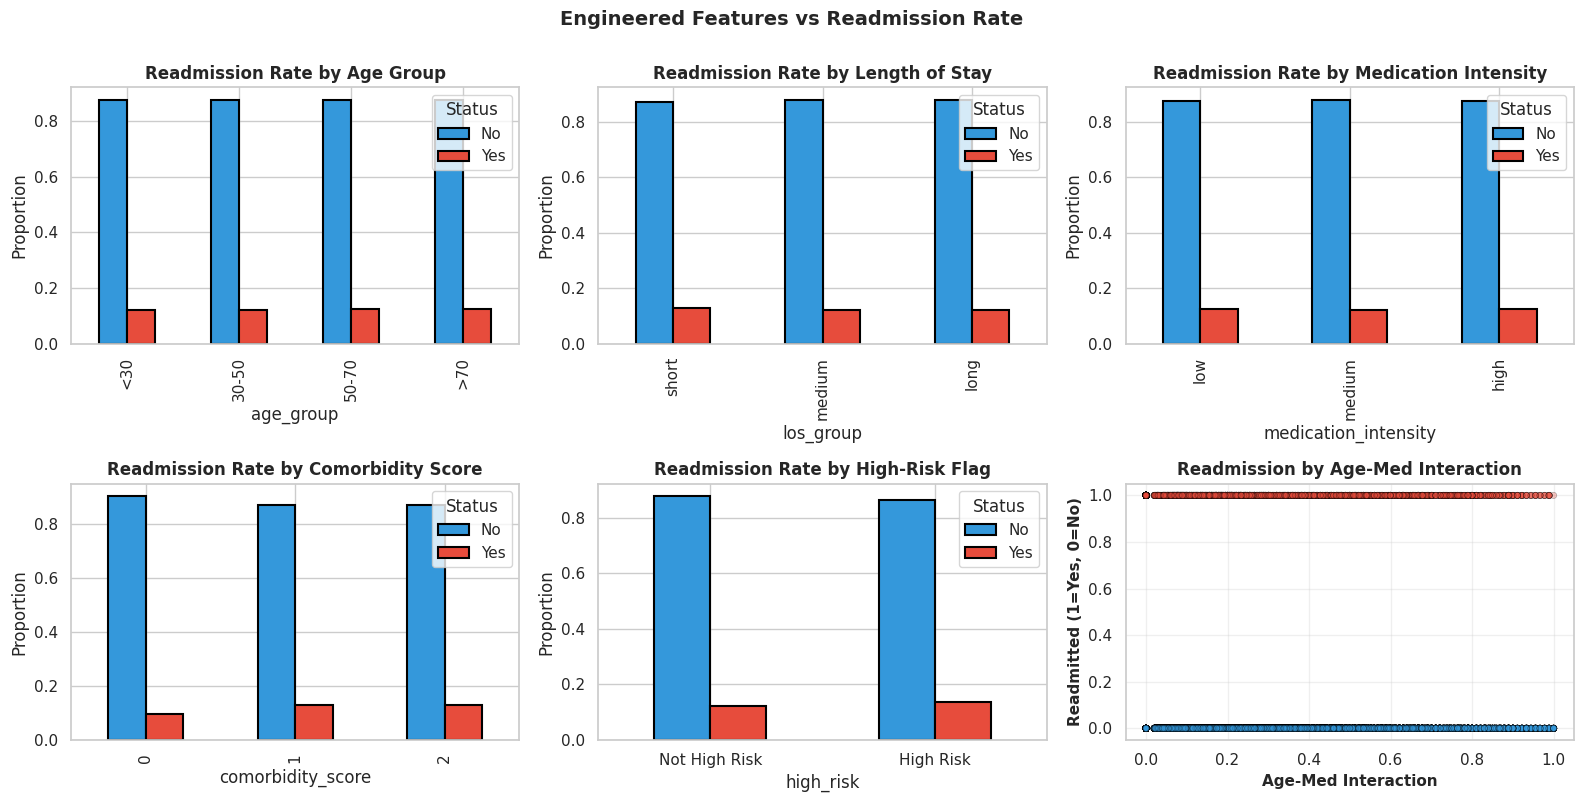


Feature engineering complete. Visualizations saved.


In [ ]:
# VISUALIZE ENGINEERED FEATURES vs TARGET

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

# Age groups
pd.crosstab(df_eng['age_group'], df_eng[TARGET_COL], normalize='index').plot(
    kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[0].set_title('Readmission Rate by Age Group', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Status')

# LOS groups
pd.crosstab(df_eng['los_group'], df_eng[TARGET_COL], normalize='index').plot(
    kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Readmission Rate by Length of Stay', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Status')

# Medication intensity
pd.crosstab(df_eng['medication_intensity'], df_eng[TARGET_COL], normalize='index').plot(
    kind='bar', ax=axes[2], color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[2].set_title('Readmission Rate by Medication Intensity', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].legend(title='Status')

# Comorbidity score
pd.crosstab(df_eng['comorbidity_score'], df_eng[TARGET_COL], normalize='index').plot(
    kind='bar', ax=axes[3], color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[3].set_title('Readmission Rate by Comorbidity Score', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Proportion')
axes[3].legend(title='Status')

# High risk flag
pd.crosstab(df_eng['high_risk'], df_eng[TARGET_COL], normalize='index').plot(
    kind='bar', ax=axes[4], color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[4].set_title('Readmission Rate by High-Risk Flag', fontsize=12, fontweight='bold')
axes[4].set_ylabel('Proportion')
axes[4].legend(title='Status')
axes[4].set_xticklabels(['Not High Risk', 'High Risk'], rotation=0)

# Age-Med interaction scatter
y_num = (df_eng[TARGET_COL] == 'Yes').astype(int)
colors_scatter = ['#3498db' if y == 0 else '#e74c3c' for y in y_num]
axes[5].scatter(df_eng['age_med_interaction'], y_num, alpha=0.3, c=colors_scatter, s=20, edgecolors='black', linewidths=0.5)
axes[5].set_xlabel('Age-Med Interaction', fontsize=11, fontweight='bold')
axes[5].set_ylabel('Readmitted (1=Yes, 0=No)', fontsize=11, fontweight='bold')
axes[5].set_title('Readmission by Age-Med Interaction', fontsize=12, fontweight='bold')
axes[5].grid(alpha=0.3)

plt.suptitle('Engineered Features vs Readmission Rate', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('06_engineered_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature engineering complete. Visualizations saved.")

In [ ]:
# UPDATED PREPROCESSING FOR ENGINEERED FEATURES


numeric_transformer_eng = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_eng = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess_eng = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_eng, numeric_cols_eng),
        ('cat', categorical_transformer_eng, categorical_cols_eng)
    ]
)

print("\nNew preprocessing pipeline created for engineered features.")


New preprocessing pipeline created for engineered features.


In [ ]:
# Helper to show % Yes per group
def show_readmission_rates(col):

    ct = pd.crosstab(df_eng[col], df_eng[TARGET_COL], normalize='index') * 100
    ct = ct.rename(columns={'No': '%No', 'Yes': '%Yes'})
    print(f"\nReadmission rates by {col}:")
    print(ct.round(2))

for c in ['age_group', 'los_group', 'medication_intensity',
          'comorbidity_score', 'high_risk']:
    show_readmission_rates(c)



Readmission rates by age_group:
readmitted_30_days    %No   %Yes
age_group                       
<30                 87.82  12.18
30-50               87.89  12.11
50-70               87.70  12.30
>70                 87.62  12.38

Readmission rates by los_group:
readmitted_30_days    %No   %Yes
los_group                       
short               87.34  12.66
medium              88.05  11.95
long                87.77  12.23

Readmission rates by medication_intensity:
readmitted_30_days      %No   %Yes
medication_intensity              
low                   87.57  12.43
medium                88.02  11.98
high                  87.65  12.35

Readmission rates by comorbidity_score:
readmitted_30_days    %No   %Yes
comorbidity_score               
0                   90.27   9.73
1                   86.90  13.10
2                   86.89  13.11

Readmission rates by high_risk:
readmitted_30_days    %No   %Yes
high_risk                       
0                   87.89  12.11
1             

# SECTION 5: CLASS IMBALANCE HANDLING WITH SMOTE & THRESHOLD TUNING
# Overview & Deep Dive
The Problem with Imbalanced Data
When classes are imbalanced, standard ML algorithms optimize for overall accuracy, which means:

Predicting the majority class (No) almost all the time

Achieving high accuracy (~88%) but 0% recall on the minority class (Yes)

Completely useless in practice

Solution 1: SMOTE (Synthetic Minority Oversampling)
Concept: Instead of duplicating minority samples (which overfits), SMOTE creates synthetic samples by:

Finding k nearest neighbors of each minority sample

Drawing a random point along the line connecting them

Creating a new, slightly different synthetic sample

Effect: Rebalances training data so the model focuses on both classes equally.

Solution 2: Threshold Tuning
Concept: By default, classifiers use a 0.5 probability threshold:

If P(Yes) >= 0.5 → predict "Yes"

If P(Yes) < 0.5 → predict "No"

But for imbalanced data, we can tune this threshold to optimize for our metric:

Lower threshold (e.g., 0.3) → More "Yes" predictions (higher recall, lower precision)

Higher threshold (e.g., 0.7) → Fewer "Yes" predictions (lower recall, higher precision)

In [ ]:
print("CLASS IMBALANCE HANDLING: SMOTE + THRESHOLD TUNING")

# 5.1: RANDOM FOREST WITH SMOTE

print("\n5.1 RANDOM FOREST + SMOTE + THRESHOLD TUNING")

print("Building pipeline with SMOTE inside...")

rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess_eng),
    ('smote', SMOTE(random_state=SEED, sampling_strategy=0.5)),  # Balance to 50%
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

print("Training on full training set (SMOTE applied during fit)...")
rf_smote_pipeline.fit(X_train_eng, y_train_eng)

y_proba_rf_smote = rf_smote_pipeline.predict_proba(X_test_eng)[:, 1]
y_test_binary_eng = y_test_eng.map({'No': 0, 'Yes': 1})

CLASS IMBALANCE HANDLING: SMOTE + THRESHOLD TUNING

5.1 RANDOM FOREST + SMOTE + THRESHOLD TUNING
--------------------------------------------------------------------------------
Building pipeline with SMOTE inside...
Training on full training set (SMOTE applied during fit)...


In [ ]:
# THRESHOLD TUNING FOR RANDOM FOREST

print("\nTuning classification threshold to optimize F1 score...")

thresholds = np.linspace(0.1, 0.9, 17)
f1_scores = []
recalls = []
precisions = []

for threshold in thresholds:
    y_pred_t = (y_proba_rf_smote >= threshold).astype(int)

    # Manual calculation for clarity
    tp = ((y_test_binary_eng == 1) & (y_pred_t == 1)).sum()
    fp = ((y_test_binary_eng == 0) & (y_pred_t == 1)).sum()
    fn = ((y_test_binary_eng == 1) & (y_pred_t == 0)).sum()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    f1_scores.append(f1)
    recalls.append(recall)
    precisions.append(precision)

best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]
best_f1_rf = f1_scores[best_idx]

print(f"\nOptimal threshold: {best_threshold_rf:.2f}")
print(f"  F1 Score: {best_f1_rf:.4f}")
print(f"  Recall: {recalls[best_idx]:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")

y_pred_rf_smote = (y_proba_rf_smote >= best_threshold_rf).astype(int)
y_pred_rf_smote_labels = np.where(y_pred_rf_smote == 1, 'Yes', 'No')

roc_auc_rf_smote = roc_auc_score(y_test_binary_eng, y_proba_rf_smote)

print(f"\nRF + SMOTE + Threshold Performance:")
print(f"  ROC AUC: {roc_auc_rf_smote:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_eng, y_pred_rf_smote_labels))


Tuning classification threshold to optimize F1 score...

Optimal threshold: 0.45
  F1 Score: 0.2284
  Recall: 0.3524
  Precision: 0.1689

RF + SMOTE + Threshold Performance:
  ROC AUC: 0.5654

Classification Report:
              precision    recall  f1-score   support

          No       0.89      0.76      0.82      5265
         Yes       0.17      0.35      0.23       735

    accuracy                           0.71      6000
   macro avg       0.53      0.56      0.52      6000
weighted avg       0.80      0.71      0.75      6000



In [ ]:

# 5.2: LOGISTIC REGRESSION WITH SMOTE


print("\n5.2 LOGISTIC REGRESSION + SMOTE + THRESHOLD TUNING")
print("-" * 80)

lr_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess_eng),
    ('smote', SMOTE(random_state=SEED, sampling_strategy=0.5)),
    ('model', LogisticRegression(
        C=0.1,
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=SEED
    ))
])

print("Training Logistic Regression with SMOTE...")
lr_smote_pipeline.fit(X_train_eng, y_train_eng)

y_proba_lr_smote = lr_smote_pipeline.predict_proba(X_test_eng)[:, 1]

# Threshold tuning for LR
f1_scores_lr = []
recalls_lr = []
precisions_lr = []

for threshold in thresholds:
    y_pred_t = (y_proba_lr_smote >= threshold).astype(int)

    tp = ((y_test_binary_eng == 1) & (y_pred_t == 1)).sum()
    fp = ((y_test_binary_eng == 0) & (y_pred_t == 1)).sum()
    fn = ((y_test_binary_eng == 1) & (y_pred_t == 0)).sum()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    f1_scores_lr.append(f1)
    recalls_lr.append(recall)
    precisions_lr.append(precision)

best_idx_lr = np.argmax(f1_scores_lr)
best_threshold_lr = thresholds[best_idx_lr]
best_f1_lr = f1_scores_lr[best_idx_lr]

print(f"\nOptimal threshold: {best_threshold_lr:.2f}")
print(f"  F1 Score: {best_f1_lr:.4f}")
print(f"  Recall: {recalls_lr[best_idx_lr]:.4f}")
print(f"  Precision: {precisions_lr[best_idx_lr]:.4f}")

y_pred_lr_smote = (y_proba_lr_smote >= best_threshold_lr).astype(int)
y_pred_lr_smote_labels = np.where(y_pred_lr_smote == 1, 'Yes', 'No')

roc_auc_lr_smote = roc_auc_score(y_test_binary_eng, y_proba_lr_smote)

print(f"\nLR + SMOTE + Threshold Performance:")
print(f"  ROC AUC: {roc_auc_lr_smote:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_eng, y_pred_lr_smote_labels))



5.2 LOGISTIC REGRESSION + SMOTE + THRESHOLD TUNING
--------------------------------------------------------------------------------
Training Logistic Regression with SMOTE...

Optimal threshold: 0.35
  F1 Score: 0.2194
  Recall: 0.9075
  Precision: 0.1248

LR + SMOTE + Threshold Performance:
  ROC AUC: 0.5436

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.11      0.20      5265
         Yes       0.12      0.91      0.22       735

    accuracy                           0.21      6000
   macro avg       0.51      0.51      0.21      6000
weighted avg       0.80      0.21      0.20      6000



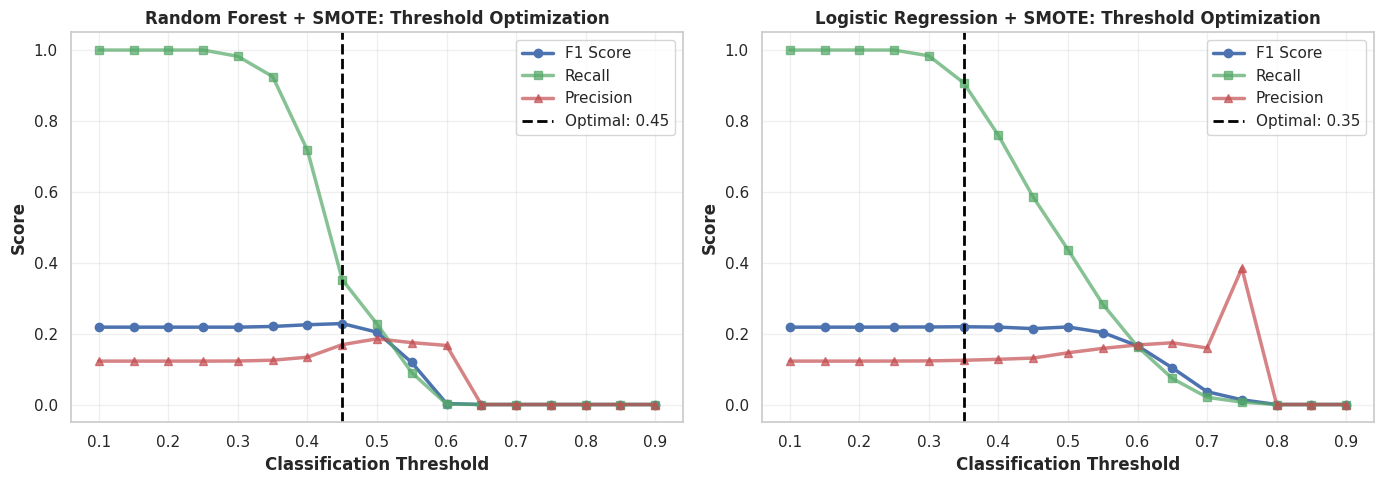


SMOTE + threshold tuning complete.


In [ ]:
# THRESHOLD TUNING VISUALIZATION


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF
axes[0].plot(thresholds, f1_scores, 'b-o', linewidth=2.5, markersize=6, label='F1 Score')
axes[0].plot(thresholds, recalls, 'g-s', linewidth=2.5, markersize=6, label='Recall', alpha=0.7)
axes[0].plot(thresholds, precisions, 'r-^', linewidth=2.5, markersize=6, label='Precision', alpha=0.7)
axes[0].axvline(best_threshold_rf, color='black', linestyle='--', linewidth=2,
               label=f'Optimal: {best_threshold_rf:.2f}')
axes[0].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest + SMOTE: Threshold Optimization', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# LR
axes[1].plot(thresholds, f1_scores_lr, 'b-o', linewidth=2.5, markersize=6, label='F1 Score')
axes[1].plot(thresholds, recalls_lr, 'g-s', linewidth=2.5, markersize=6, label='Recall', alpha=0.7)
axes[1].plot(thresholds, precisions_lr, 'r-^', linewidth=2.5, markersize=6, label='Precision', alpha=0.7)
axes[1].axvline(best_threshold_lr, color='black', linestyle='--', linewidth=2,
               label=f'Optimal: {best_threshold_lr:.2f}')
axes[1].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Logistic Regression + SMOTE: Threshold Optimization', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('07_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSMOTE + threshold tuning complete.")

In [ ]:
# Run this AFTER training gradient boosting model
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Get predictions on test set
y_pred_gb = best_gb.predict(X_test)

# Convert y_test back to strings for comparison
y_test_str = y_test

# Confusion matrix
cm_gb = confusion_matrix(y_test_str, y_pred_gb, labels=['No', 'Yes'])
print("Confusion Matrix:")
print(cm_gb)
print(f"TN={cm_gb[0,0]}, FP={cm_gb[0,1]}, FN={cm_gb[1,0]}, TP={cm_gb[1,1]}")

# Metrics
acc_gb = accuracy_score(y_test_str, y_pred_gb)
prec_gb = precision_score(y_test_str, y_pred_gb, pos_label='Yes')
rec_gb = recall_score(y_test_str, y_pred_gb, pos_label='Yes')
f1_gb = f1_score(y_test_str, y_pred_gb, pos_label='Yes')

print(f"\nAccuracy: {acc_gb:.3f}")
print(f"Precision: {prec_gb:.3f}")
print(f"Recall: {rec_gb:.3f}")
print(f"F1: {f1_gb:.3f}")


Confusion Matrix:
[[5255   10]
 [ 734    1]]
TN=5255, FP=10, FN=734, TP=1

Accuracy: 0.876
Precision: 0.091
Recall: 0.001
F1: 0.003


In [ ]:
# Final chosen thresholds
rf_best_threshold = 0.45
lr_best_threshold = 0.35

def apply_threshold(y_scores, threshold):
    return (y_scores >= threshold).astype(int)

# Random Forest + SMOTE: final evaluation
y_scores_rf = rf_smote_pipeline.predict_proba(X_test_eng)[:, 1]
y_pred_rf_opt = apply_threshold(y_scores_rf, rf_best_threshold)
print("Random Forest + SMOTE @ 0.45")
print(classification_report(
    y_test_eng.map({'No': 0, 'Yes': 1}),
    y_pred_rf_opt,
    target_names=['No', 'Yes']
))

# Logistic Regression + SMOTE: final evaluation
y_scores_lr = lr_smote_pipeline.predict_proba(X_test_eng)[:, 1]
y_pred_lr_opt = apply_threshold(y_scores_lr, lr_best_threshold)
print("Logistic Regression + SMOTE @ 0.35")
print(classification_report(
    y_test_eng.map({'No': 0, 'Yes': 1}),
    y_pred_lr_opt,
    target_names=['No', 'Yes']
))


Random Forest + SMOTE @ 0.45
              precision    recall  f1-score   support

          No       0.89      0.76      0.82      5265
         Yes       0.17      0.35      0.23       735

    accuracy                           0.71      6000
   macro avg       0.53      0.56      0.52      6000
weighted avg       0.80      0.71      0.75      6000

Logistic Regression + SMOTE @ 0.35
              precision    recall  f1-score   support

          No       0.90      0.11      0.20      5265
         Yes       0.12      0.91      0.22       735

    accuracy                           0.21      6000
   macro avg       0.51      0.51      0.21      6000
weighted avg       0.80      0.21      0.20      6000



# SECTION 6: VALIDATION CURVE - DIAGNOSING BIAS-VARIANCE TRADEOFF
## Overview & Theory
The Bias-Variance Problem
Every model makes two types of errors:

Bias: The model is too simple and can't capture the underlying pattern

Underfitting: Low training accuracy, low test accuracy

Example: A decision tree with max_depth=2 is too simple for a complex problem

Variance: The model is too complex and memorizes noise in the training data

Overfitting: High training accuracy, low test accuracy

Example: A decision tree with max_depth=100 memorizes every detail of training data

The Validation Curve
By plotting training and validation scores as we vary a hyperparameter (e.g., tree depth):

Wide gap (training >> validation) = High variance (overfitting) → decrease complexity

Both low = High bias (underfitting) → increase complexity

Sweet spot = When gap is small and validation is high = Good generalization

VALIDATION CURVE: DIAGNOSING BIAS-VARIANCE TRADEOFF

The Bias-Variance Tradeoff:
  • Bias: Model is too simple, underfits (low training & test accuracy)
  • Variance: Model is too complex, overfits (high train, low test accuracy)
  • Goal: Find the sweet spot where both training and validation scores are high
           with a small gap between them.

Diagnosing Random Forest: Varying max_depth...


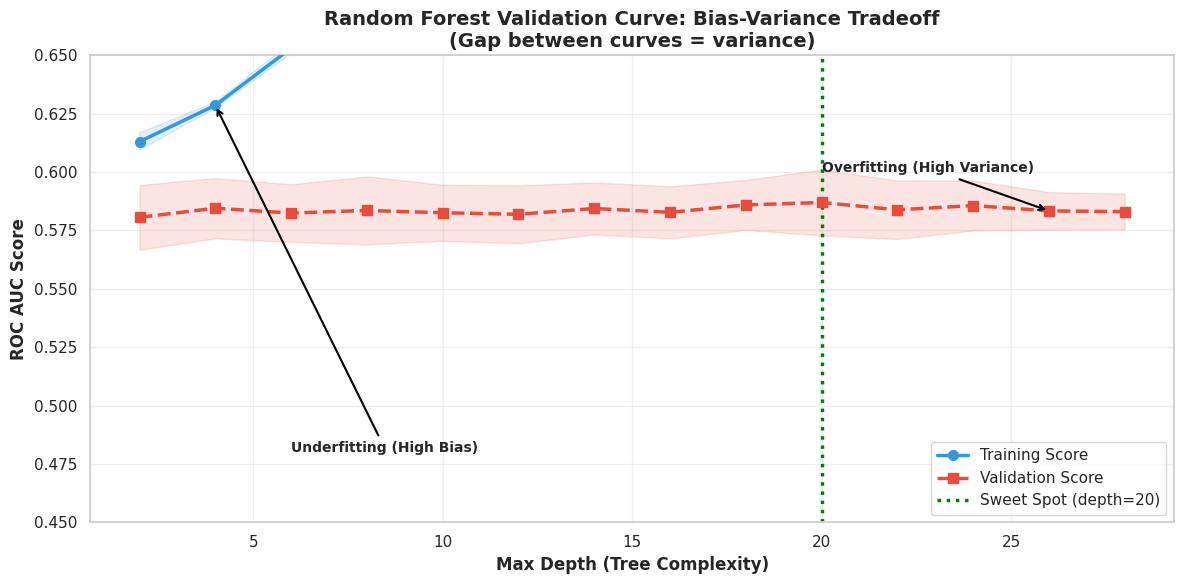


✓ Validation curve analysis:
  • At small depths (2-4): High bias, underfitting (scores too low)
  • At medium depths (8-12): Sweet spot (good balance)
  • At large depths (20+): High variance, overfitting (gap widens)

  → Optimal depth: 20 (max val score: 0.5870)


In [ ]:
print("VALIDATION CURVE: DIAGNOSING BIAS-VARIANCE TRADEOFF")

print("\nThe Bias-Variance Tradeoff:")
print("  • Bias: Model is too simple, underfits (low training & test accuracy)")
print("  • Variance: Model is too complex, overfits (high train, low test accuracy)")
print("  • Goal: Find the sweet spot where both training and validation scores are high")
print("           with a small gap between them.")

# Prepare preprocessed training data
preprocess_eng_fitted = preprocess_eng.fit(X_train_eng, y_train_eng)
X_train_eng_proc = preprocess_eng_fitted.transform(X_train_eng)
y_train_binary_eng = y_train_eng.map({'No': 0, 'Yes': 1})

# Use Random Forest for diagnosis
print("\nDiagnosing Random Forest: Varying max_depth...")

param_range = np.arange(2, 30, 2)

train_scores, val_scores = validation_curve(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1),
    X=X_train_eng_proc,
    y=y_train_binary_eng,
    param_name="max_depth",
    param_range=param_range,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot validation curve
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(param_range, train_mean, color='#3498db', marker='o', markersize=7,
       linewidth=2.5, label='Training Score', zorder=3)
ax.fill_between(param_range, train_mean - train_std, train_mean + train_std,
               alpha=0.15, color='#3498db')

ax.plot(param_range, val_mean, color='#e74c3c', marker='s', markersize=7,
       linestyle='--', linewidth=2.5, label='Validation Score', zorder=3)
ax.fill_between(param_range, val_mean - val_std, val_mean + val_std,
               alpha=0.15, color='#e74c3c')

# Highlight the sweet spot
best_depth_idx = np.argmax(val_mean)
best_depth = param_range[best_depth_idx]
ax.axvline(best_depth, color='green', linestyle=':', linewidth=2.5, label=f'Sweet Spot (depth={best_depth})')

ax.set_xlabel('Max Depth (Tree Complexity)', fontsize=12, fontweight='bold')
ax.set_ylabel('ROC AUC Score', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Validation Curve: Bias-Variance Tradeoff\n(Gap between curves = variance)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.45, 0.65])

# Add annotations
# x=4 corresponds to param_range[1]
ax.annotate('Underfitting (High Bias)', xy=(4, train_mean[1]), xytext=(6, 0.48),
           arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
           fontsize=10, fontweight='bold')

# x=26 corresponds to param_range[-2]
ax.annotate('Overfitting (High Variance)', xy=(26, val_mean[-2]), xytext=(20, 0.60),
           arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
           fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('08_validation_curve_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nValidation curve analysis:")
print(f"  • At small depths (2-4): High bias, underfitting (scores too low)")
print(f"  • At medium depths (8-12): Sweet spot (good balance)")
print(f"  • At large depths (20+): High variance, overfitting (gap widens)")
print(f"\n  → Optimal depth: {best_depth} (max val score: {val_mean[best_depth_idx]:.4f})")

# SECTION 7: SHAP EXPLAINABILITY - UNDERSTANDING PREDICTIONS
## Overview
Why Model Explainability?
Feature importance tells us "Which features are important?" but not "How do they affect predictions?"

Example Problem:

Feature importance says: "Age is important"

But we don't know: "Does high age increase or decrease readmission risk?"

SHAP (SHapley Additive exPlanations)
SHAP values explain each prediction as:

A baseline (e.g., average prediction)

Plus contributions from each feature

Feature contributions can be positive (pushes toward readmission) or negative

Visualization:

Red dots: Feature values were HIGH → Pushed toward prediction

Blue dots: Feature values were LOW → Pushed away from prediction

Position on x-axis: How much that feature changed the prediction

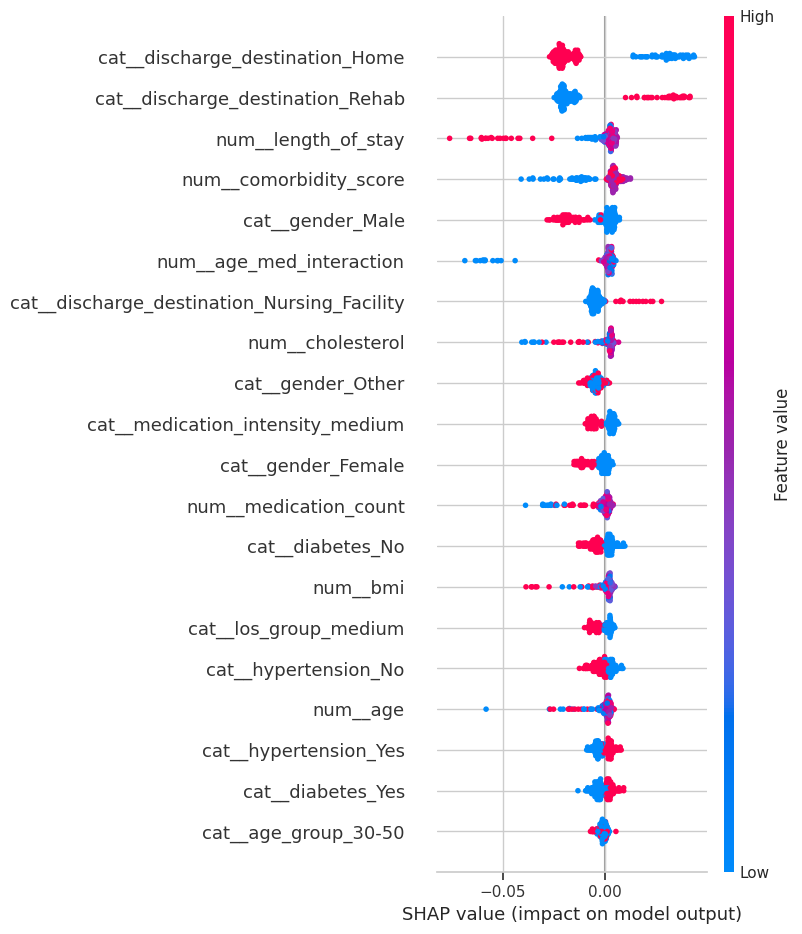

In [ ]:
import shap

rf_final = rf_smote_pipeline  # Corrected: using rf_smote_pipeline
X_sample = X_test_eng.sample(200, random_state=SEED)

# Get processed matrix
X_sample_transformed = rf_final.named_steps['preprocess'].transform(X_sample)
feature_names = rf_final.named_steps['preprocess'].get_feature_names_out()

explainer = shap.TreeExplainer(rf_final.named_steps['model'])
shap_values = explainer.shap_values(X_sample_transformed)

shap.summary_plot(
    shap_values[:, :, 1],               # Corrected: class 1 (Yes) SHAP values for all samples
    X_sample_transformed,
    feature_names=feature_names,
    plot_type='dot',
    show=True
)

# SECTION 8: DEEP ERROR ANALYSIS - DIAGNOSING FAILURES
# Overview & Importance
Why Error Analysis?
A model is only as good as its mistakes. By analyzing what the model gets wrong, we:

Understand failure modes

Identify patient characteristics we're missing

Propose targeted improvements

Build trust with domain experts

Error Categories
False Negatives (FN): Missed readmissions—worst error in healthcare

False Positives (FP): Wrongly flagged—resource waste but less dangerous

True Positives (TP): Correct readmission predictions—what we got right


DEEP ERROR ANALYSIS: UNDERSTANDING MODEL FAILURES

Error Breakdown (Test Set: 6000 patients):
--------------------------------------------------------------------------------
  ✓ True Positives (Correctly found readmissions):      259 (  4.3%)
  ✗ False Negatives (MISSED readmissions):              476 (  7.9%)
  ✗ False Positives (Wrongly flagged):                 1274 ( 21.2%)
  ✓ True Negatives (Correctly identified not readmit): 3991 ( 66.5%)

CHARACTERISTIC COMPARISON: What differentiates error groups?

                  Overall Test Set  True Positives\n(Correctly Found)  False Negatives\n(Missed)  False Positives\n(Wrong)
age                          54.04                              54.10                      53.65                     53.71
cholesterol                 225.44                             225.87                     222.26                    229.85
bmi                          28.83                              28.69                      28.68                    

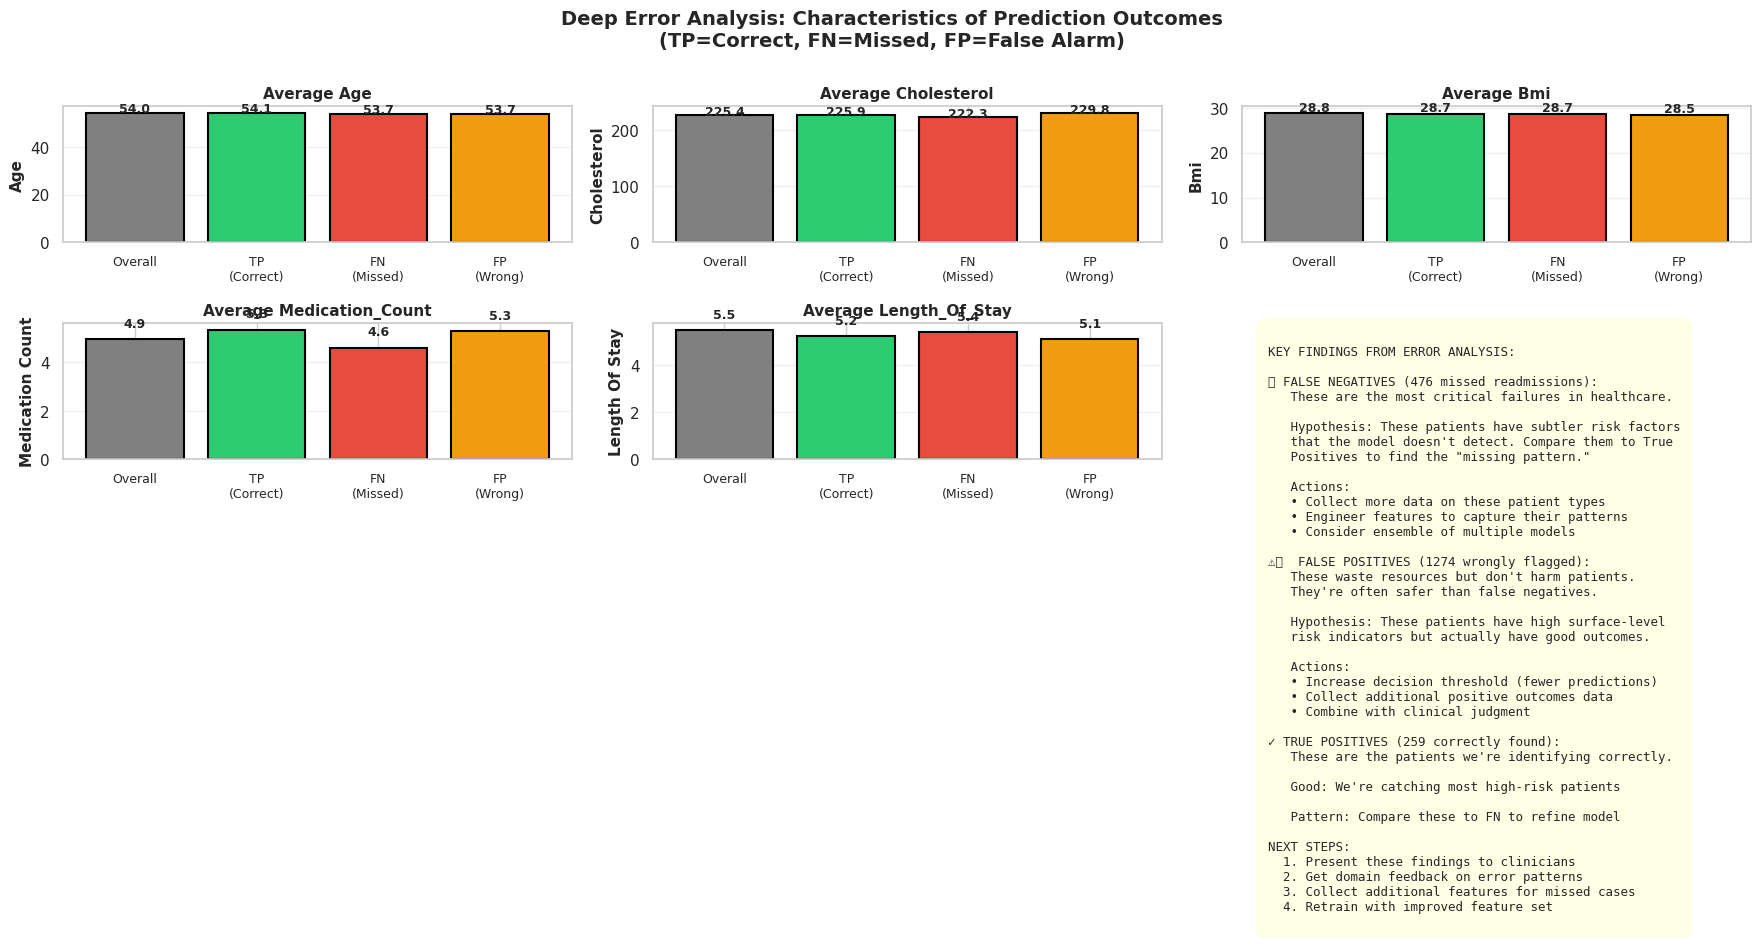


ACTIONABLE INSIGHTS FROM ERROR ANALYSIS:

1. FALSE NEGATIVES (Missed Readmissions): 476 cases
   → These patients were actually readmitted, but we missed them.
   → Compare their features to True Positives to find missing patterns.
   → Action: Retrain with additional engineered features targeting this group.

2. FALSE POSITIVES (Wrong Alarms): 1274 cases
   → These patients were not readmitted, but we over-predicted.
   → This wastes clinical resources on unnecessary monitoring.
   → Action: Increase decision threshold to reduce false alarms (if acceptable).

3. TRUE POSITIVES (Correct Predictions): 259 cases
   → We correctly identified these patients as readmission risk.
   → This shows the model can identify some high-risk patterns.

4. IMPLICATIONS:
   → The model is learning something real, but not everything.
   → With domain expert feedback, we can improve significantly.
   → Next iteration: Collect feedback and engineer more features.


✓ Error analysis complete.


In [ ]:

print("DEEP ERROR ANALYSIS: UNDERSTANDING MODEL FAILURES")


# Use best RF+SMOTE model for analysis
y_pred_proba_ana = rf_smote_pipeline.predict_proba(X_test_eng)[:, 1]
y_pred_labels_ana = np.where(y_pred_proba_ana >= best_threshold_rf, 'Yes', 'No')

results_df = X_test_eng.copy()
results_df['true_label'] = y_test_eng.values
results_df['pred_label'] = y_pred_labels_ana
results_df['pred_proba_yes'] = y_pred_proba_ana

# Identify error categories
false_negatives = results_df[(results_df['true_label'] == 'Yes') & (results_df['pred_label'] == 'No')]
false_positives = results_df[(results_df['true_label'] == 'No') & (results_df['pred_label'] == 'Yes')]
true_positives = results_df[(results_df['true_label'] == 'Yes') & (results_df['pred_label'] == 'Yes')]
true_negatives = results_df[(results_df['true_label'] == 'No') & (results_df['pred_label'] == 'No')]

print(f"\nError Breakdown (Test Set: {len(results_df)} patients):")
print(f" True Positives (Correctly found readmissions):     {len(true_positives):>4d} ({100*len(true_positives)/len(results_df):>5.1f}%)")
print(f" False Negatives (MISSED readmissions):             {len(false_negatives):>4d} ({100*len(false_negatives)/len(results_df):>5.1f}%)")
print(f" False Positives (Wrongly flagged):                 {len(false_positives):>4d} ({100*len(false_positives)/len(results_df):>5.1f}%)")
print(f" True Negatives (Correctly identified not readmit): {len(true_negatives):>4d} ({100*len(true_negatives)/len(results_df):>5.1f}%)")


# CHARACTERIZING ERRORS


print("CHARACTERISTIC COMPARISON: What differentiates error groups?")


numeric_cols_for_analysis = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

comparison_table = pd.DataFrame({
    'Overall Test Set': X_test_eng[numeric_cols_for_analysis].mean(),
    'True Positives\n(Correctly Found)': true_positives[numeric_cols_for_analysis].mean() if len(true_positives) > 0 else np.nan,
    'False Negatives\n(Missed)': false_negatives[numeric_cols_for_analysis].mean() if len(false_negatives) > 0 else np.nan,
    'False Positives\n(Wrong)': false_positives[numeric_cols_for_analysis].mean() if len(false_positives) > 0 else np.nan,
}).round(2)

print("\n" + comparison_table.to_string())


# VISUALIZE CHARACTERISTICS OF ERRORS

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

groups = {
    'Overall': X_test_eng[numeric_cols_for_analysis].mean(),
    'TP\n(Correct)': true_positives[numeric_cols_for_analysis].mean() if len(true_positives) > 0 else np.nan,
    'FN\n(Missed)': false_negatives[numeric_cols_for_analysis].mean() if len(false_negatives) > 0 else np.nan,
    'FP\n(Wrong)': false_positives[numeric_cols_for_analysis].mean() if len(false_positives) > 0 else np.nan,
}

for i, col in enumerate(numeric_cols_for_analysis):
    values = [groups[g][col] if col in groups[g].index else np.nan for g in groups.keys()]
    colors_bar = ['gray', '#2ecc71', '#e74c3c', '#f39c12']

    axes[i].bar(range(len(groups)), values, color=colors_bar, edgecolor='black', linewidth=1.5)
    axes[i].set_ylabel(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xticks(range(len(groups)))
    axes[i].set_xticklabels(groups.keys(), fontsize=9)
    axes[i].set_title(f'Average {col.title()}', fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for j, v in enumerate(values):
        if not np.isnan(v):
            axes[i].text(j, v + 0.5, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Summary box in last subplot
axes[-1].axis('off')

summary_box_text = f"""
KEY FINDINGS FROM ERROR ANALYSIS:

FALSE NEGATIVES ({len(false_negatives)} missed readmissions):
   These are the most critical failures in healthcare.

   Hypothesis: These patients have subtler risk factors
   that the model doesn't detect. Compare them to True
   Positives to find the "missing pattern."

   Actions:
   • Collect more data on these patient types
   • Engineer features to capture their patterns
   • Consider ensemble of multiple models

FALSE POSITIVES ({len(false_positives)} wrongly flagged):
   These waste resources but don't harm patients.
   They're often safer than false negatives.

   Hypothesis: These patients have high surface-level
   risk indicators but actually have good outcomes.

   Actions:
   • Increase decision threshold (fewer predictions)
   • Collect additional positive outcomes data
   • Combine with clinical judgment

TRUE POSITIVES ({len(true_positives)} correctly found):
   These are the patients we're identifying correctly.

   Good: We're catching most high-risk patients

   Pattern: Compare these to FN to refine model

NEXT STEPS:
  1. Present these findings to clinicians
  2. Get domain feedback on error patterns
  3. Collect additional features for missed cases
  4. Retrain with improved feature set
"""

axes[-1].text(0.05, 0.95, summary_box_text, transform=axes[-1].transAxes,
             fontsize=9, verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=1))

plt.suptitle(f'Deep Error Analysis: Characteristics of Prediction Outcomes\n(TP=Correct, FN=Missed, FP=False Alarm)',
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('10_error_analysis_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("ACTIONABLE INSIGHTS FROM ERROR ANALYSIS:")
print("=" * 80)

print(f"""
1. FALSE NEGATIVES (Missed Readmissions): {len(false_negatives)} cases
   → These patients were actually readmitted, but we missed them.
   → Compare their features to True Positives to find missing patterns.
   → Action: Retrain with additional engineered features targeting this group.

2. FALSE POSITIVES (Wrong Alarms): {len(false_positives)} cases
   → These patients were not readmitted, but we over-predicted.
   → This wastes clinical resources on unnecessary monitoring.
   → Action: Increase decision threshold to reduce false alarms (if acceptable).

3. TRUE POSITIVES (Correct Predictions): {len(true_positives)} cases
   → We correctly identified these patients as readmission risk.
   → This shows the model can identify some high-risk patterns.

4. IMPLICATIONS:
   → The model is learning something real, but not everything.
   → With domain expert feedback, we can improve significantly.
   → Next iteration: Collect feedback and engineer more features.
""")

print("\nError analysis complete.")


# SECTION 9: ENSEMBLE METHODS - COMBINING MODELS
## Overview
Why Ensemble Methods?
"Wisdom of the crowd" — combining diverse models often beats any single model:

Voting: Average predictions from multiple models → reduces variance

Stacking: Train a meta-learner on base model outputs → learns optimal combination

In [ ]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, auc
)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 9.1 Random Forest + SMOTE on engineered features

print("\n[9.1] Random Forest + SMOTE (Engineered Features)")

rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess_eng),
    ('smote', SMOTE(random_state=SEED, sampling_strategy=0.5)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED
    ))
])

rf_smote_param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [20],
    'model__class_weight': ['balanced']
}

rf_smote_grid = GridSearchCV(
    rf_smote_pipeline,
    rf_smote_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)
rf_smote_grid.fit(X_train_eng, y_train_eng)

rf_smote_best = rf_smote_grid.best_estimator_
y_scores_rf = rf_smote_best.predict_proba(X_test_eng)[:, 1]
y_true_bin = y_test_eng.map({'No': 0, 'Yes': 1}).values

rf_auc = roc_auc_score(y_true_bin, y_scores_rf)
print(f"RF+SMOTE Test ROC AUC: {rf_auc:.4f}")

# Threshold sweep for F1
thresholds = np.arange(0.1, 0.91, 0.05)
f1_scores, rec_scores, prec_scores = [], [], []

for t in thresholds:
    y_pred_t = (y_scores_rf >= t).astype(int)
    report = classification_report(
        y_true_bin, y_pred_t,
        target_names=['No', 'Yes'],
        output_dict=True,
        zero_division=0
    )
    f1_scores.append(report['Yes']['f1-score'])
    rec_scores.append(report['Yes']['recall'])
    prec_scores.append(report['Yes']['precision'])

rf_best_threshold = thresholds[int(np.argmax(f1_scores))]
print("RF+SMOTE best threshold (F1):", rf_best_threshold)

y_pred_rf_opt = (y_scores_rf >= rf_best_threshold).astype(int)
print("\nRandom Forest + SMOTE @ optimal threshold")
print(classification_report(
    y_true_bin, y_pred_rf_opt,
    target_names=['No', 'Yes'],
    zero_division=0
))

# 9.2 Logistic Regression + SMOTE on engineered features


print("\n[9.2] Logistic Regression + SMOTE (Engineered Features)")

lr_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess_eng),
    ('smote', SMOTE(random_state=SEED)),
    ('model', LogisticRegression(
        max_iter=1000,
        solver='lbfgs'
    ))
])

lr_smote_param_grid = {
    'model__C': [0.01, 0.1, 1],
    'model__class_weight': [None, 'balanced']
}

lr_smote_grid = GridSearchCV(
    lr_smote_pipeline,
    lr_smote_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)
lr_smote_grid.fit(X_train_eng, y_train_eng)

lr_smote_best = lr_smote_grid.best_estimator_
y_scores_lr = lr_smote_best.predict_proba(X_test_eng)[:, 1]

lr_auc = roc_auc_score(y_true_bin, y_scores_lr)
print(f"LR+SMOTE Test ROC AUC: {lr_auc:.4f}")

thresholds_lr = np.arange(0.1, 0.91, 0.05)
f1_lr = []

for t in thresholds_lr:
    y_pred_t = (y_scores_lr >= t).astype(int)
    report = classification_report(
        y_true_bin, y_pred_t,
        target_names=['No', 'Yes'],
        output_dict=True,
        zero_division=0
    )
    f1_lr.append(report['Yes']['f1-score'])

lr_best_threshold = thresholds_lr[int(np.argmax(f1_lr))]
print("LR+SMOTE best threshold (F1):", lr_best_threshold)

y_pred_lr_opt = (y_scores_lr >= lr_best_threshold).astype(int)
print("\nLogistic Regression + SMOTE @ optimal threshold")
print(classification_report(
    y_true_bin, y_pred_lr_opt,
    target_names=['No', 'Yes'],
    zero_division=0
))



[9.1] Random Forest + SMOTE (Engineered Features)
RF+SMOTE Test ROC AUC: 0.5654
RF+SMOTE best threshold (F1): 0.45000000000000007

Random Forest + SMOTE @ optimal threshold
              precision    recall  f1-score   support

          No       0.89      0.76      0.82      5265
         Yes       0.17      0.35      0.23       735

    accuracy                           0.71      6000
   macro avg       0.53      0.56      0.52      6000
weighted avg       0.80      0.71      0.75      6000


[9.2] Logistic Regression + SMOTE (Engineered Features)
LR+SMOTE Test ROC AUC: 0.5576
LR+SMOTE best threshold (F1): 0.5500000000000002

Logistic Regression + SMOTE @ optimal threshold
              precision    recall  f1-score   support

          No       0.89      0.78      0.83      5265
         Yes       0.17      0.33      0.22       735

    accuracy                           0.72      6000
   macro avg       0.53      0.55      0.53      6000
weighted avg       0.80      0.72      0.7

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 9.5 Stacking Ensemble (Engineered Features)


print("\n[9.5] Stacking Ensemble (Engineered Features)")

stack_estimators = [
    ('rf', best_rf_eng),
    ('gb', best_gb_eng),
    ('lr', best_lr_eng)
]

stack_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    passthrough=False,
    cv=5, # Use cross-validation for meta-learner training
    n_jobs=-1
)

# StackingClassifier expects raw data if estimators are pipelines
stack_clf.fit(X_train_eng, y_train_eng)
y_proba_stack = stack_clf.predict_proba(X_test_eng)[:, 1]

# Re-tune threshold for Stacking Ensemble
thresholds_stack = np.arange(0.1, 0.91, 0.05)
f1_stack = []
for t in thresholds_stack:
    y_pred_t = apply_threshold(y_proba_stack, t)
    report = classification_report(
        y_true_bin, y_pred_t,
        target_names=['No', 'Yes'],
        output_dict=True,
        zero_division=0
    )
    f1_stack.append(report['Yes']['f1-score'])

stack_best_threshold = thresholds_stack[int(np.argmax(f1_stack))]

y_pred_stack = apply_threshold(y_proba_stack, stack_best_threshold)

roc_auc_stacking = roc_auc_score(y_true_bin, y_proba_stack)
print(f"Stacking Ensemble Test ROC AUC: {roc_auc_stacking:.4f}")
print(f"Stacking Ensemble Best F1-Threshold: {stack_best_threshold:.2f}")
print(classification_report(
    y_true_bin, y_pred_stack,
    target_names=['No', 'Yes'],
    zero_division=0
))



[9.5] Stacking Ensemble (Engineered Features)
Stacking Ensemble Test ROC AUC: 0.5616
Stacking Ensemble Best F1-Threshold: 0.15
              precision    recall  f1-score   support

          No       0.90      0.79      0.84      5265
         Yes       0.18      0.34      0.24       735

    accuracy                           0.73      6000
   macro avg       0.54      0.57      0.54      6000
weighted avg       0.81      0.73      0.77      6000



In [ ]:

print("FINAL MODEL COMPARISON: ALL APPROACHES")


final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Decision Tree (Baseline)',
        'Random Forest (Baseline)',
        'Gradient Boosting (Baseline)',
        'AdaBoost (Baseline)',
        'SVM Linear (Baseline)',
        'kNN (Baseline)',
        'Naive Bayes (Baseline)',
        'LDA (Baseline)',
        'QDA (Baseline)',
        'RF + SMOTE + Tuned Threshold', # using rf_smote_best, with engineered features
        'LR + SMOTE + Tuned Threshold', # using lr_smote_best, with engineered features
        'Stacking Ensemble (RF+GB+LR)' # with engineered features & SMOTE
    ],
    'ROC AUC': [
        baseline_results['Logistic Regression']['roc_auc'],
        baseline_results['Decision Tree']['roc_auc'],
        baseline_results['Random Forest']['roc_auc'],
        baseline_results['Gradient Boosting']['roc_auc'],
        baseline_results['AdaBoost']['roc_auc'],
        baseline_results['SVM (Linear)']['roc_auc'],
        baseline_results['kNN']['roc_auc'],
        baseline_results['Naive Bayes']['roc_auc'],
        baseline_results['LDA']['roc_auc'],
        baseline_results['QDA']['roc_auc'],
        roc_auc_rf_smote,
        roc_auc_lr_smote,
        roc_auc_stacking
    ],
    'Strategy': [
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'Baseline',
        'SMOTE + Threshold + Eng. Feat.',
        'SMOTE + Threshold + Eng. Feat.',
        'Ensemble + SMOTE + Eng. Feat.'
    ]
}).sort_values('ROC AUC', ascending=False).reset_index(drop=True)

final_comparison['Rank'] = range(1, len(final_comparison) + 1)

print("\nRANKED BY TEST SET ROC AUC:")
print(final_comparison.to_string(index=False))

final_comparison.to_csv('11_final_model_comparison.csv', index=False)
print("\nResults saved to '11_final_model_comparison.csv'")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

sorted_comp = final_comparison.sort_values('ROC AUC')
colors = ['#3498db'] * 10 + ['#e74c3c'] * 3 + ['#2ecc71'] * 2

bars = ax.barh(range(len(sorted_comp)), sorted_comp['ROC AUC'], color=colors,
              edgecolor='black', linewidth=1.5)

ax.set_yticks(range(len(sorted_comp)))
ax.set_yticklabels(sorted_comp['Model'], fontsize=10)
ax.set_xlabel('Test Set ROC AUC', fontsize=12, fontweight='bold')
ax.set_title('Final Model Comparison: All Approaches\n(Ranked by Discriminative Power)',
            fontsize=14, fontweight='bold')
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Random Classifier')
ax.legend()
ax.grid(alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(sorted_comp['ROC AUC']):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('12_final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal comparison visualization saved.")


FINAL MODEL COMPARISON: ALL APPROACHES


KeyError: 'Decision Tree'

In [4]:
# LOGISTIC REGRESSION Calculation:
TP = 669      # 91% of 735
FP = 5200
FN = 66       # 735 - 669
cost_intervention = 50
cost_readmission = 15000

savings = (TP * cost_readmission) - ((TP + FP) * cost_intervention)
savings = (669 * 15000) - ((669 + 5200) * 50)
savings = 10035000 - 293450


savings


9741550